# 20. Capstone project: from business question to deployed model

The twenty notebooks before this one have each taken one piece of the machine-learning
workflow apart. This one puts the pieces back together. The first part is a complete, worked project on
the course's churn data — not a toy version, but the sequence of decisions a practitioner
actually makes: turning a vague business wish ("reduce churn") into a measurable
prediction problem with a budget, cleaning the data, building a leak-free pipeline,
comparing models honestly, choosing a decision rule that respects the budget, quantifying
uncertainty, analysing errors, explaining the model, auditing it for fairness, packaging it
with documentation, scoring new data, and planning how to watch it in production. The
second part hands the same structure to you: a project template, three alternative
briefs with milestones, a grading rubric, and advice on presenting results and on where
to go next.

Nothing here is new. Every step points back to the notebook that introduced it, and the
point of the exercise is to see how the steps constrain each other: the metric follows
from the business decision, the split from the metric, the features from the data
problems, the model choice from the validation protocol, the threshold from the budget,
the monitoring plan from the assumptions that the model card had to state.

**Prerequisites:** all of notebooks 3–7 and 12; notebooks 10, 17, 18 and 19 are used
directly.

## Learning objectives

After working through this notebook you will be able to

- translate a business objective into an ML task with a success metric, a budget constraint, a baseline and explicit constraints (latency, fairness, interpretability);
- run the full workflow end to end — cleaning, leak-free preprocessing pipeline, model comparison with cross-validated uncertainty, a small hyper-parameter search, model selection by the one-standard-error rule;
- turn probabilities into decisions under a budget by ranking on expected value, and evaluate the decision with a gains curve;
- report held-out performance with bootstrap confidence intervals and an error analysis by segment;
- produce global and local explanations and a fairness check, and know what to do with what they show;
- persist a pipeline with metadata and a model card, score a new file in batch, and write a monitoring plan;
- write a project report that a decision maker can act on, and plan and grade a project of your own.

## Setup

In [1]:
import json
import hashlib
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from course_utils import set_style, PALETTE, load_churn

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()
pd.set_option("display.width", 140)          # the comparison tables below are wide; show them in full
pd.set_option("display.max_columns", 20)
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
T_START = time.perf_counter()

# Part I — A worked project: the churn retention campaign

## 1. Framing the problem

**The business situation.** A telecom-style company loses about a third of its customers
per year. The retention team can call a limited number of customers each month and offer
them a discount; they currently pick customers by gut feeling. They ask: *which customers
should we call?*

**From wish to decision.** "Reduce churn" is not a prediction problem; "choose which 15 %
of customers to call this month so that the campaign saves as much revenue as possible" is
a decision problem, and it needs a prediction — the probability that each customer will
churn — as one input. Writing the decision down forces every other choice:

| Question | Answer for this project | Notebook |
|---|---|---|
| Prediction target | `churned` (binary): does the customer leave in the coming period? | 7 |
| Unit of decision | a customer, scored once per monthly campaign (batch; latency irrelevant) | 18 |
| Budget | the team can contact **15 %** of customers | 7 |
| Value of a correct decision | a churner who is contacted stays with probability $s = 0.3$ and then pays $H = 12$ more months of their monthly charge | — |
| Cost of a contact | $c = 10$ (call time + offer handling), whether or not the customer would have churned | — |
| Primary metric | **expected saved revenue** of the contacted set; secondary: precision among the contacted 15 % (*precision@15 %*) | 7 |
| Model-quality metrics (for selection) | ROC AUC, average precision, log loss — threshold-free, so they do not depend on the budget | 7 |
| Constraints | probabilities must be *calibrated* (they enter an expected-value calculation); the model must be explainable to the retention team; the offer is a benefit, so selection rates across `senior_citizen` and `region` must be checked | 7, 17, 19 |
| Baselines | contact customers at random; contact month-to-month customers with the highest bills | 5 |

For customer $i$ with churn probability $p_i$ and monthly charge $m_i$, the **expected net
value of a contact** is

$$
v_i \;=\; p_i \cdot s \cdot H \cdot m_i \;-\; c ,
$$

and under a budget of $k$ contacts the optimal policy is to contact the $k$ customers
with the largest $v_i$ (notebook 7's cost-sensitive decision, applied per customer). The
value model is crude — it ignores customers who would have stayed anyway and take the
discount, and it assumes $s$ is the same for everyone — and the report must say so; a
better campaign design (a randomised control group, *uplift* modelling) is discussed in
section 12 and exercise 3.

In [2]:
BUDGET = 0.15          # fraction of customers the retention team can contact
S_RETAIN = 0.30        # probability that a contacted churner stays
HORIZON = 12           # months of revenue saved by a retained customer
C_CONTACT = 10.0       # cost of one contact

def expected_value(p_churn, monthly_charges):
    """Expected net value of contacting each customer (same units as monthly charges)."""
    return p_churn * S_RETAIN * HORIZON * np.asarray(monthly_charges) - C_CONTACT

def realised_value(y_true, monthly_charges, contacted):
    """Value of a campaign with known outcomes: revenue saved from the contacted churners minus contact costs."""
    y_true, mc, contacted = (np.asarray(a) for a in (y_true, monthly_charges, contacted))
    saved = S_RETAIN * HORIZON * np.sum(mc[contacted & (y_true == 1)])
    return saved - C_CONTACT * contacted.sum()

def top_k_mask(scores, budget=BUDGET):
    """Boolean mask selecting the `budget` fraction of customers with the highest scores."""
    scores = np.asarray(scores)
    k = int(np.ceil(budget * len(scores)))
    mask = np.zeros(len(scores), dtype=bool)
    mask[np.argsort(-scores)[:k]] = True
    return mask

def precision_at_budget(y_true, scores, budget=BUDGET):
    mask = top_k_mask(scores, budget)
    return np.asarray(y_true)[mask].mean()

print(f"a contact pays off in expectation when p_churn > {C_CONTACT / (S_RETAIN * HORIZON * 70):.2f} for a customer paying 70 per month")

a contact pays off in expectation when p_churn > 0.04 for a customer paying 70 per month


## 2. Data understanding and cleaning

We start from the *raw* file, exactly as notebook 3 found it, and apply the cleaning that
notebook 4 developed: duplicated customers, inconsistent capitalisation in `region`,
impossible monthly charges (999), and `total_charges` missing for brand-new customers.
The cleaning is written as a function because the batch-scoring step (section 11) has to
apply the same steps to new files.

In [3]:
def clean_churn(raw):
    """The cleaning steps of notebook 4, as a function so that new files can be treated identically."""
    df = raw.drop_duplicates(subset="customer_id").copy()
    df["region"] = df["region"].str.title()
    df.loc[df["monthly_charges"] > 200, "monthly_charges"] = np.nan      # 999 = data-entry error
    return df.reset_index(drop=True)

raw = load_churn(raw=True)
churn = clean_churn(raw)
print(f"raw file: {raw.shape[0]} rows -> {churn.shape[0]} unique customers")
print(f"region values: {sorted(churn['region'].unique())}")
print(f"missing values:\n{churn.isna().sum()[churn.isna().sum() > 0]}")
print(f"churn rate: {churn['churned'].mean():.3f}")

raw file: 5005 rows -> 5000 unique customers
region values: ['East', 'North', 'South', 'West']
missing values:
monthly_charges      3
total_charges      154
dtype: int64
churn rate: 0.326


Three data-quality problems and what the cleaning did to them — the picture a reviewer
needs in order to believe the rest of the report.

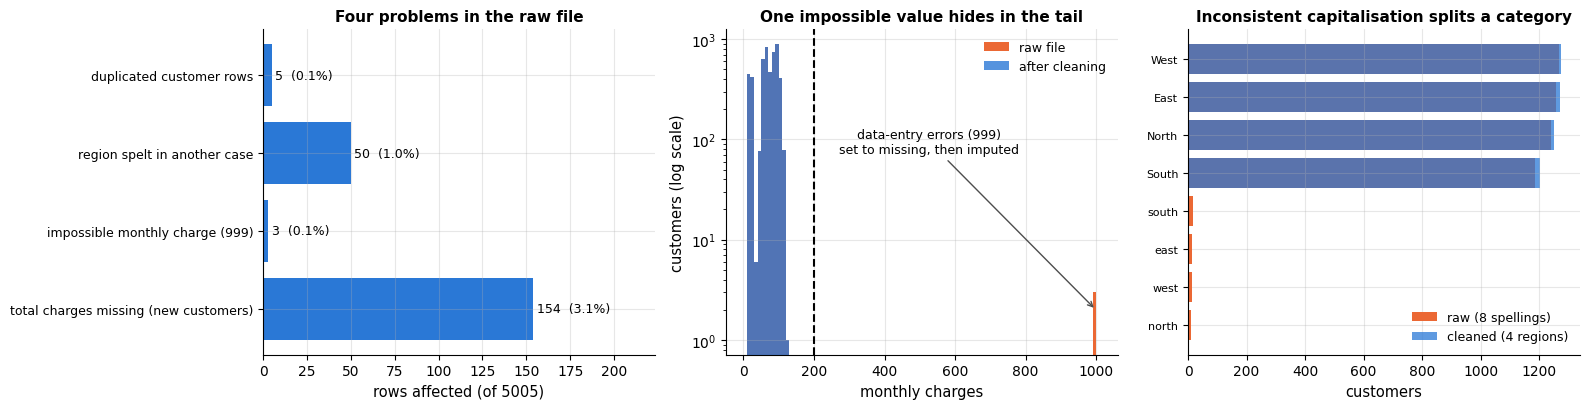

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

issues = {"duplicated customer rows": int(raw.duplicated(subset="customer_id").sum()),
          "region spelt in another case": int((raw["region"] != raw["region"].str.title()).sum()),
          "impossible monthly charge (999)": int((raw["monthly_charges"] > 200).sum()),
          "total charges missing (new customers)": int(raw["total_charges"].isna().sum())}
axes[0].barh(list(issues)[::-1], list(issues.values())[::-1], color=PALETTE[0])
for i, v in enumerate(list(issues.values())[::-1]):
    axes[0].text(v + 2, i, f"{v}  ({v / len(raw):.1%})", va="center", fontsize=9)
axes[0].set_xlim(0, max(issues.values()) * 1.45)
axes[0].set_xlabel(f"rows affected (of {len(raw)})")
axes[0].set_title("Four problems in the raw file", fontsize=11)
axes[0].tick_params(axis="y", labelsize=9)

charge_edges = np.linspace(0, 1010, 102)
axes[1].hist(raw["monthly_charges"].dropna(), bins=charge_edges, color=PALETTE[1], label="raw file")
axes[1].hist(churn["monthly_charges"].dropna(), bins=charge_edges, color=PALETTE[0], alpha=0.8, label="after cleaning")
axes[1].axvline(200, color="black", ls="--", lw=1.5)
axes[1].annotate("data-entry errors (999)\nset to missing, then imputed",
                 xy=(999, 2), xytext=(0.52, 0.62), textcoords="axes fraction",
                 fontsize=9, ha="center", arrowprops=dict(arrowstyle="->", color="0.3"))
axes[1].set_yscale("log")
axes[1].set_xlabel("monthly charges")
axes[1].set_ylabel("customers (log scale)")
axes[1].set_title("One impossible value hides in the tail", fontsize=11)
axes[1].legend(fontsize=9)

before = raw["region"].value_counts()
after = churn["region"].value_counts()
axes[2].barh(before.index[::-1], before.to_numpy()[::-1], color=PALETTE[1], label=f"raw ({len(before)} spellings)")
axes[2].barh(after.index[::-1], after.to_numpy()[::-1], color=PALETTE[0], alpha=0.75,
             label=f"cleaned ({len(after)} regions)")
axes[2].set_xlabel("customers")
axes[2].set_title("Inconsistent capitalisation splits a category", fontsize=11)
axes[2].legend(fontsize=9, loc="lower right")
axes[2].tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

A short, target-oriented look at the data (notebook 3) — enough to know what a good model
should have learned, and to sanity-check it later.

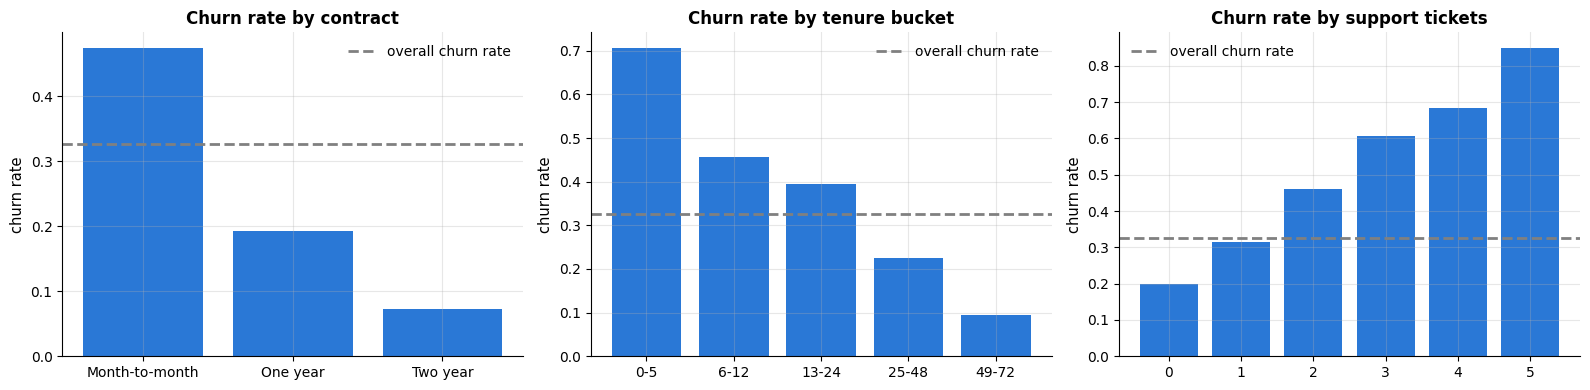

In [5]:
churn["tenure_bucket"] = pd.cut(churn["tenure_months"], bins=[-1, 5, 12, 24, 48, 72],
                                labels=["0-5", "6-12", "13-24", "25-48", "49-72"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["contract", "tenure_bucket", "support_tickets"]):
    rate = churn.groupby(col, observed=True)["churned"].agg(["mean", "size"])
    rate = rate[rate["size"] >= 30]
    ax.bar(rate.index.astype(str), rate["mean"], color=PALETTE[0])
    ax.axhline(churn["churned"].mean(), color="gray", ls="--", label="overall churn rate")
    ax.set_title(f"Churn rate by {col.replace('_', ' ')}")
    ax.set_ylabel("churn rate")
    ax.legend()
plt.tight_layout()
plt.show()
churn = churn.drop(columns="tenure_bucket")

Churn is concentrated in month-to-month contracts, in the first months of tenure, and
among customers who opened support tickets — the shape a retention team would recognise.

**Split first.** Before any feature engineering that involves fitting, we set aside a
stratified 20 % test set (notebook 5). It is touched exactly once, in section 7.

In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(churn, test_size=0.2, stratify=churn["churned"], random_state=RANDOM_STATE)
print(f"train+validation: {len(train_df)} customers ({train_df['churned'].mean():.3f} churn)   "
      f"test: {len(test_df)} customers ({test_df['churned'].mean():.3f} churn)")

train+validation: 4000 customers (0.327 churn)   test: 1000 customers (0.326 churn)


## 3. Feature engineering and the preprocessing pipeline

Feature engineering (notebook 4) is where domain knowledge enters. We add a handful of
features that encode what the EDA showed and what a retention manager would mention:

- `new_customer` — tenure below six months (the early-life churn spike is non-linear, and a linear model cannot see it otherwise);
- `charges_ratio` — total charges divided by what the current monthly charge times tenure would predict: a value far from 1 means the bill changed recently;
- `tickets_per_year` — support tickets normalised by tenure (three tickets in three months is not the same as three in six years);
- `n_services` — how many add-on services the customer uses (a proxy for how entangled they are with the product).

Row-wise features like these need no fitting and can live in a plain function; anything
that *is* fitted (imputation, scaling, encoding) goes into the `ColumnTransformer` so
that it is fitted on training folds only. Identifiers and the signup date are dropped:
the date is redundant with tenure, and an ID is at best noise and at worst a leak.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "support_tickets", "senior_citizen",
           "has_partner", "tech_support", "streaming", "new_customer", "charges_ratio", "tickets_per_year", "n_services"]
CATEGORICAL = ["contract", "payment_method", "internet_service", "region"]
TARGET = "churned"

def add_features(df):
    """Row-wise feature engineering (no fitting involved, so it can run before the split and on new files)."""
    d = df.copy()
    tenure = d["tenure_months"].clip(lower=1)
    d["new_customer"] = (d["tenure_months"] < 6).astype(int)
    d["charges_ratio"] = d["total_charges"] / (d["monthly_charges"] * tenure)
    d["tickets_per_year"] = d["support_tickets"] / (tenure / 12)
    d["n_services"] = d["tech_support"] + d["streaming"] + (d["internet_service"] != "No").astype(int)
    d[NUMERIC] = d[NUMERIC].astype(float)          # float columns: needed by partial-dependence tools later
    return d

def make_preprocessor():
    numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    return ColumnTransformer([("num", numeric_pipe, NUMERIC),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])

X_trval = add_features(train_df)[NUMERIC + CATEGORICAL]
y_trval = train_df[TARGET].to_numpy()
X_test = add_features(test_df)[NUMERIC + CATEGORICAL]
y_test = test_df[TARGET].to_numpy()
print(f"feature matrix: {X_trval.shape[1]} columns -> {make_preprocessor().fit_transform(X_trval).shape[1]} after encoding")
X_trval.head(3)

feature matrix: 16 columns -> 26 after encoding


,tenure_months,monthly_charges,total_charges,support_tickets,senior_citizen,has_partner,tech_support,streaming,new_customer,charges_ratio,tickets_per_year,n_services,contract,payment_method,internet_service,region
1776,25.0,52.11,1302.81,0.0,1.0,0.0,0.0,0.0,0.0,1.000046,0.000000,1.0,One year,Electronic check,DSL,East
2096,34.0,90.61,3065.28,4.0,0.0,0.0,0.0,0.0,0.0,0.994982,1.411765,1.0,Month-to-month,Mailed check,Fiber optic,North
3518,5.0,89.12,NaN,2.0,0.0,1.0,0.0,0.0,1.0,NaN,4.800000,1.0,Month-to-month,Mailed check,Fiber optic,West


## 4. Baselines and a first model comparison

Every model is evaluated with the same stratified 5-fold cross-validation, with several
metrics at once, and reported as mean ± standard error (notebook 5). We include the
dummy classifier and the two business heuristics, so that the table answers the question
the retention team will ask first: *is this better than what we do now?*

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"ROC AUC": "roc_auc", "avg precision": "average_precision", "log loss": "neg_log_loss",
           "precision@15%": make_scorer(precision_at_budget, response_method="predict_proba")}

cv_scores = {}                             # raw per-fold scores, for the figure below

def cv_summary(name, estimator, X, y):
    res = cross_validate(estimator, X, y, cv=cv, scoring=SCORING, n_jobs=2)
    cv_scores[name] = {metric: res[f"test_{metric}"] for metric in SCORING}
    row = {"model": name}
    for metric in SCORING:
        s = res[f"test_{metric}"]
        row[metric] = f"{s.mean():.3f} ± {s.std(ddof=1) / np.sqrt(len(s)):.3f}"
    row["fit time (s)"] = f"{res['fit_time'].mean():.2f}"
    return row

def heuristic_scores(X):
    """Business rule: month-to-month customers first, highest monthly charge first within a contract type."""
    return (X["contract"] == "Month-to-month").astype(float) * 1000 + X["monthly_charges"].fillna(0)

candidates = {
    "majority-class dummy": DummyClassifier(strategy="prior"),
    "logistic regression": LogisticRegression(max_iter=2000),
    "random forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=2, random_state=RANDOM_STATE),
    "hist. gradient boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
rows = []
for name, est in candidates.items():
    rows.append(cv_summary(name, Pipeline([("prep", make_preprocessor()), ("model", est)]), X_trval, y_trval))

# the heuristic has no fit; evaluate it on the same folds
heur = [precision_at_budget(y_trval[va], heuristic_scores(X_trval.iloc[va])) for _, va in cv.split(X_trval, y_trval)]
cv_scores["heuristic: month-to-month, highest bill"] = {"precision@15%": np.array(heur)}
rows.append({"model": "heuristic: month-to-month, highest bill", "precision@15%": f"{np.mean(heur):.3f} ± {np.std(heur, ddof=1) / np.sqrt(5):.3f}"})
comparison = pd.DataFrame(rows).set_index("model").fillna("—")
comparison

,ROC AUC,avg precision,log loss,precision@15%,fit time (s)
model,,,,,
majority-class dummy,0.500 ± 0.000,0.326 ± 0.000,-0.632 ± 0.000,0.340 ± 0.008,0.01
logistic regression,0.857 ± 0.007,0.763 ± 0.010,-0.431 ± 0.010,0.855 ± 0.013,0.02
random forest,0.852 ± 0.006,0.753 ± 0.007,-0.438 ± 0.007,0.835 ± 0.014,0.67
hist. gradient boosting,0.839 ± 0.006,0.737 ± 0.008,-0.469 ± 0.009,0.832 ± 0.012,0.22
"heuristic: month-to-month, highest bill",—,—,—,0.728 ± 0.006,—


A table of numbers with "±" in it is hard to read and easy to over-read. The same
information as a dot-and-error-bar chart — mean over the five folds, bar of one standard
error — shows at a glance which differences are real and which are noise.

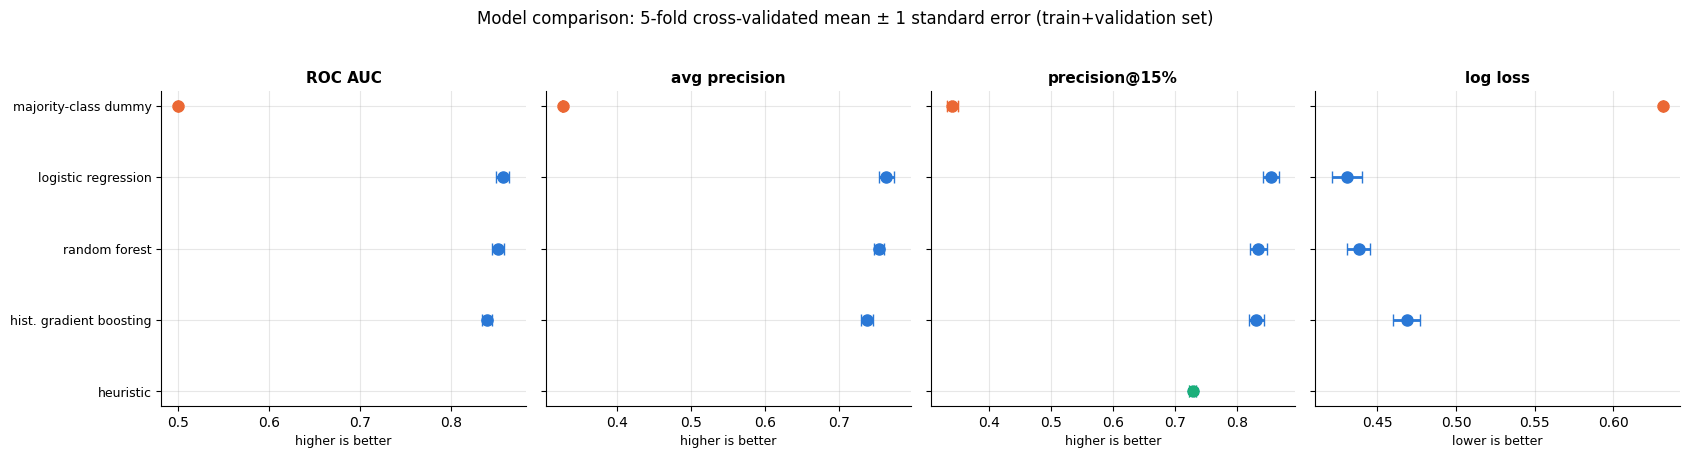

In [9]:
panel_metrics = ["ROC AUC", "avg precision", "precision@15%", "log loss"]
model_order = list(cv_scores)[::-1]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4), sharey=True)
for ax, metric in zip(axes, panel_metrics):
    for i, name in enumerate(model_order):
        vals = cv_scores[name].get(metric)
        if vals is None:
            continue
        vals = -vals if metric == "log loss" else vals          # neg_log_loss -> log loss
        color = PALETTE[2] if "heuristic" in name else (PALETTE[1] if "dummy" in name else PALETTE[0])
        ax.errorbar(vals.mean(), i, xerr=vals.std(ddof=1) / np.sqrt(len(vals)), fmt="o", ms=8,
                    capsize=4, color=color)
    ax.set_yticks(range(len(model_order)))
    ax.set_yticklabels([n.split(":")[0] for n in model_order], fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("lower is better" if metric == "log loss" else "higher is better", fontsize=9)
fig.suptitle("Model comparison: 5-fold cross-validated mean ± 1 standard error (train+validation set)", y=1.03)
plt.tight_layout()
plt.show()

Three things to take from the table and the chart. The business heuristic is a *strong*
baseline — a precision of 0.73 among the customers it would call, against 0.34 for the
dummy — which is usual, and which is why it must be in the table. All three learned models
beat it clearly, and the best two are within about one standard error of each other, so the
table alone does not pick a winner between them. And the untuned boosting model is the
weakest of the three on every metric: with 4 000 rows its default depth and learning rate
overfit slightly (notebook 10), which is what tuning is for.

## 5. Tuning and model selection

A large search is not warranted by differences this small. We tune the two most
promising families with a *small* random search (notebook 12; `n_iter` in the single
digits, 5-fold CV, average precision as the objective because the campaign only cares
about the top of the ranking), then apply the **one-standard-error rule**: among the
configurations whose score is within one standard error of the best, take the simplest.

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

lr_search = RandomizedSearchCV(
    Pipeline([("prep", make_preprocessor()), ("model", LogisticRegression(max_iter=3000))]),
    {"model__C": loguniform(1e-3, 1e2)}, n_iter=6, cv=cv, scoring="average_precision",
    random_state=RANDOM_STATE, n_jobs=2)
hgb_search = RandomizedSearchCV(
    Pipeline([("prep", make_preprocessor()), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
    {"model__learning_rate": loguniform(0.02, 0.3), "model__max_iter": randint(40, 160),
     "model__max_leaf_nodes": randint(4, 32), "model__min_samples_leaf": randint(10, 80),
     "model__l2_regularization": loguniform(1e-3, 10)},
    n_iter=6, cv=cv, scoring="average_precision", random_state=RANDOM_STATE, n_jobs=2)

searches = {"logistic regression (tuned)": lr_search, "hist. gradient boosting (tuned)": hgb_search}
for name, search in searches.items():
    t0 = time.perf_counter()
    search.fit(X_trval, y_trval)
    best = search.cv_results_
    se = best["std_test_score"][search.best_index_] / np.sqrt(cv.get_n_splits())
    print(f"{name:34s} best CV avg precision {search.best_score_:.3f} ± {se:.3f}   "
          f"({search.n_iter} candidates, {time.perf_counter() - t0:.0f} s)")
print("best boosting configuration:", {k.replace("model__", ""): (round(v, 3) if isinstance(v, float) else v)
                                        for k, v in hgb_search.best_params_.items()})

logistic regression (tuned)        best CV avg precision 0.763 ± 0.009   (6 candidates, 0 s)
hist. gradient boosting (tuned)    best CV avg precision 0.757 ± 0.011   (6 candidates, 3 s)
best boosting configuration: {'l2_regularization': np.float64(0.401), 'learning_rate': np.float64(0.023), 'max_iter': 127, 'max_leaf_nodes': 15, 'min_samples_leaf': 39}


In [11]:
scores = {name: s.best_score_ for name, s in searches.items()}
std_errs = {name: s.cv_results_["std_test_score"][s.best_index_] / np.sqrt(cv.get_n_splits()) for name, s in searches.items()}
best_name = max(scores, key=scores.get)
cutoff = scores[best_name] - std_errs[best_name]
# candidates ordered from simplest to most complex; take the first within one SE of the best
for name in ["logistic regression (tuned)", "hist. gradient boosting (tuned)"]:
    if scores[name] >= cutoff:
        FINAL_NAME = name
        break
final_model = searches[FINAL_NAME].best_estimator_          # already refitted on all of train+validation
print(f"best score: {best_name} ({scores[best_name]:.3f}); one-SE cutoff {cutoff:.3f}")
print(f"selected by the one-standard-error rule: {FINAL_NAME}")

best score: logistic regression (tuned) (0.763); one-SE cutoff 0.754
selected by the one-standard-error rule: logistic regression (tuned)


The selection rule is easier to defend when it is drawn. Every candidate of both searches,
with its cross-validated average precision and one standard error, against the cutoff line:
everything to the right of the line is statistically tied with the best, and among those we
take the simplest model.

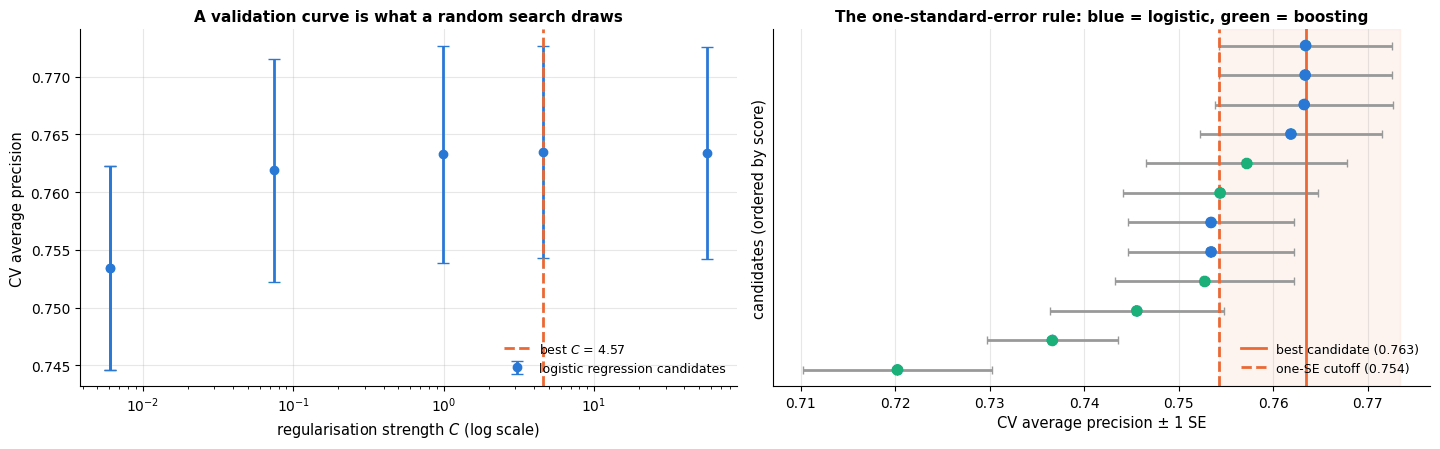

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))

lr_res = lr_search.cv_results_
lr_C = np.array([float(c) for c in lr_res["param_model__C"]])
axes[0].errorbar(lr_C, lr_res["mean_test_score"],
                 yerr=lr_res["std_test_score"] / np.sqrt(cv.get_n_splits()),
                 fmt="o", capsize=4, color=PALETTE[0], label="logistic regression candidates")
axes[0].axvline(float(lr_search.best_params_["model__C"]), color=PALETTE[1], ls="--", lw=2,
                label=f"best $C$ = {float(lr_search.best_params_['model__C']):.3g}")
axes[0].set_xscale("log")
axes[0].set_xlabel("regularisation strength $C$ (log scale)")
axes[0].set_ylabel("CV average precision")
axes[0].set_title("A validation curve is what a random search draws", fontsize=11)
axes[0].legend(fontsize=9, loc="lower right")

candidates_all = []
for family, search in searches.items():
    res = search.cv_results_
    for i in range(len(res["mean_test_score"])):
        candidates_all.append({"family": family, "score": res["mean_test_score"][i],
                               "se": res["std_test_score"][i] / np.sqrt(cv.get_n_splits())})
candidates_all = pd.DataFrame(candidates_all).sort_values("score").reset_index(drop=True)
colors = [PALETTE[0] if f.startswith("logistic") else PALETTE[2] for f in candidates_all["family"]]
axes[1].errorbar(candidates_all["score"], np.arange(len(candidates_all)), xerr=candidates_all["se"],
                 fmt="none", ecolor="0.6", capsize=3)
axes[1].scatter(candidates_all["score"], np.arange(len(candidates_all)), c=colors, s=55, zorder=3)
axes[1].axvline(scores[best_name], color=PALETTE[1], lw=2, label=f"best candidate ({scores[best_name]:.3f})")
axes[1].axvline(cutoff, color=PALETTE[1], ls="--", lw=2, label=f"one-SE cutoff ({cutoff:.3f})")
axes[1].axvspan(cutoff, candidates_all["score"].max() + 0.01, color=PALETTE[1], alpha=0.07)
axes[1].set_yticks([])
axes[1].set_ylabel("candidates (ordered by score)")
axes[1].set_xlabel("CV average precision ± 1 SE")
axes[1].set_title("The one-standard-error rule: blue = logistic, green = boosting", fontsize=11)
axes[1].legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

> **Why it matters.** On tabular data with well-engineered features a linear model is
> often within noise of a tuned ensemble (Grinsztajn et al., 2022, find that trees win
> mainly when features are raw and interactions matter). When two models are
> statistically tied, the simpler one is cheaper to run, easier to explain to the
> retention team, and usually better calibrated — all constraints from section 1. Do not
> pick the more sophisticated model because it is more sophisticated.

A learning curve (notebook 5) tells us whether collecting more customers would help.

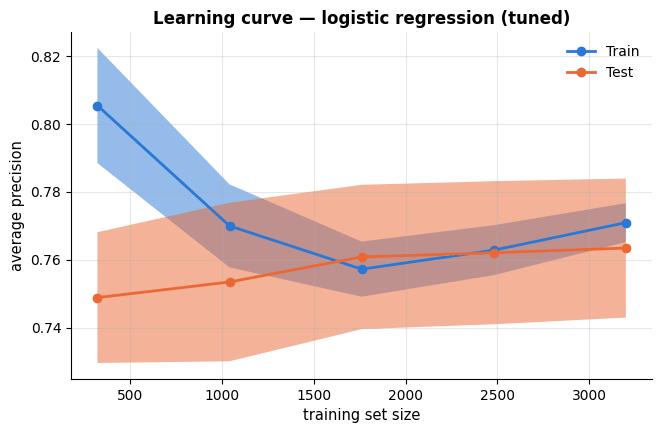

In [13]:
from sklearn.model_selection import LearningCurveDisplay

fig, ax = plt.subplots()
LearningCurveDisplay.from_estimator(final_model, X_trval, y_trval, train_sizes=np.linspace(0.1, 1.0, 5), cv=cv,
                                    scoring="average_precision", score_type="both", ax=ax,
                                    line_kw={"marker": "o"}, std_display_style="fill_between")
ax.set_title(f"Learning curve — {FINAL_NAME}")
ax.set_xlabel("training set size")
ax.set_ylabel("average precision")
plt.show()

The validation curve has flattened and the train–validation gap is small: the model is
not variance-limited, and more rows of the *same* features would buy little. Better
features (usage data, competitor offers, customer-service transcripts) would be the way
to improve it.

## 6. Calibration and the budget-constrained decision

The expected-value formula multiplies probabilities by money, so the probabilities must
mean what they say. We check calibration on *out-of-fold* predictions (never on training
predictions) with a reliability diagram and the Brier score (notebook 7).

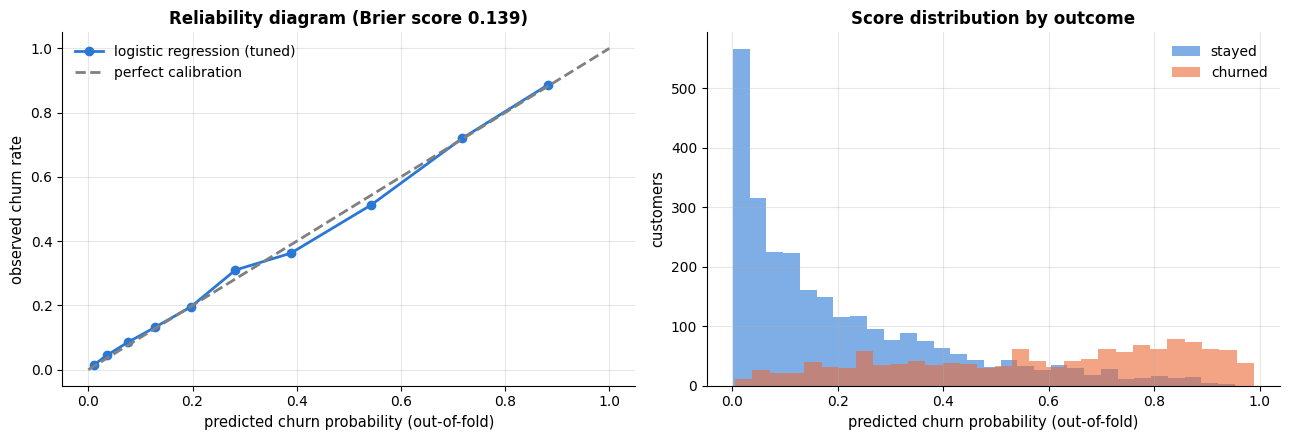

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

p_oof = cross_val_predict(final_model, X_trval, y_trval, cv=cv, method="predict_proba")[:, 1]
frac_pos, mean_pred = calibration_curve(y_trval, p_oof, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(mean_pred, frac_pos, marker="o", label=FINAL_NAME)
axes[0].plot([0, 1], [0, 1], color="gray", ls="--", label="perfect calibration")
axes[0].set_xlabel("predicted churn probability (out-of-fold)")
axes[0].set_ylabel("observed churn rate")
axes[0].set_title(f"Reliability diagram (Brier score {brier_score_loss(y_trval, p_oof):.3f})")
axes[0].legend()
axes[1].hist(p_oof[y_trval == 0], bins=30, alpha=0.6, color=PALETTE[0], label="stayed")
axes[1].hist(p_oof[y_trval == 1], bins=30, alpha=0.6, color=PALETTE[1], label="churned")
axes[1].set_xlabel("predicted churn probability (out-of-fold)")
axes[1].set_ylabel("customers")
axes[1].set_title("Score distribution by outcome")
axes[1].legend()
plt.tight_layout()
plt.show()

The curve follows the diagonal closely, so we use the probabilities as they are. What the
alternative looks like is worth seeing once: a random forest with fully grown trees does
*not* follow the diagonal, and an isotonic calibration layer
(`CalibratedClassifierCV`, notebook 7) repairs part of the difference. We fit both on 75 % of the
training data and draw the diagram on the remaining quarter, which neither has seen.

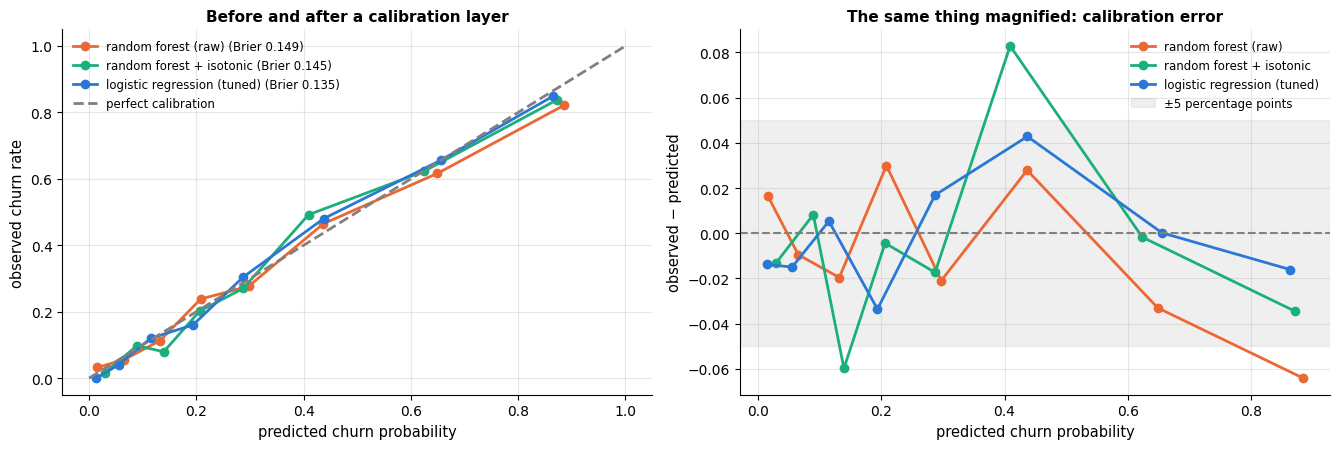

In [15]:
from sklearn.calibration import CalibratedClassifierCV

fit_idx, cal_idx = train_test_split(np.arange(len(y_trval)), test_size=0.25,
                                    stratify=y_trval, random_state=RANDOM_STATE)
rf_raw = Pipeline([("prep", make_preprocessor()),
                   ("model", RandomForestClassifier(n_estimators=150, n_jobs=2, random_state=RANDOM_STATE))])
rf_raw.fit(X_trval.iloc[fit_idx], y_trval[fit_idx])
rf_cal = CalibratedClassifierCV(rf_raw, method="isotonic", cv=3).fit(X_trval.iloc[fit_idx], y_trval[fit_idx])

held_out = (X_trval.iloc[cal_idx], y_trval[cal_idx])
curves = {"random forest (raw)": rf_raw.predict_proba(held_out[0])[:, 1],
          "random forest + isotonic": rf_cal.predict_proba(held_out[0])[:, 1],
          FINAL_NAME: final_model.predict_proba(held_out[0])[:, 1]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for (name, p), color in zip(curves.items(), [PALETTE[1], PALETTE[2], PALETTE[0]]):
    frac, mean_p = calibration_curve(held_out[1], p, n_bins=8, strategy="quantile")
    axes[0].plot(mean_p, frac, marker="o", color=color,
                 label=f"{name} (Brier {brier_score_loss(held_out[1], p):.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls="--", label="perfect calibration")
axes[0].set_xlabel("predicted churn probability")
axes[0].set_ylabel("observed churn rate")
axes[0].set_title("Before and after a calibration layer", fontsize=11)
axes[0].legend(fontsize=8.5, loc="upper left")

for (name, p), color in zip(curves.items(), [PALETTE[1], PALETTE[2], PALETTE[0]]):
    frac, mean_p = calibration_curve(held_out[1], p, n_bins=8, strategy="quantile")
    axes[1].plot(mean_p, frac - mean_p, marker="o", color=color, label=name)
axes[1].axhline(0, color="gray", ls="--", lw=1.5)
axes[1].axhspan(-0.05, 0.05, color="0.6", alpha=0.15, label="±5 percentage points")
axes[1].set_xlabel("predicted churn probability")
axes[1].set_ylabel("observed − predicted")
axes[1].set_title("The same thing magnified: calibration error", fontsize=11)
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.show()

The effect is mild here — 150 trees on an easy signal are already close to the diagonal —
but the magnified panel shows its direction: this forest is slightly *over*-confident at
both ends, predicting 0.88 where the observed churn rate is 0.82 and 0.20 where the rate
is 0.24. The isotonic layer pulls both ends in and improves the Brier score from 0.149 to
0.145. (Forests are often described as *under*-confident, because averaging many votes
shrinks probabilities towards the middle; with fully grown trees on a strong signal the
votes are nearly unanimous and the shrinkage goes the other way. The diagram, not the
folklore, decides — which is the reason to draw it.) Our selected model is the best
calibrated of the three (Brier 0.135) without any extra layer, which is one more argument
for it (exercise 4 repeats the comparison for the boosting model).

Now the decision. For every customer we compute the expected net value $v_i$ of a
contact and rank on it; the campaign takes the top 15 %. A **gains curve** shows, for any
budget, how much value the campaign realises if it follows the model's ranking versus
the heuristic's or a random order — computed here on the out-of-fold predictions so that
the test set stays untouched.

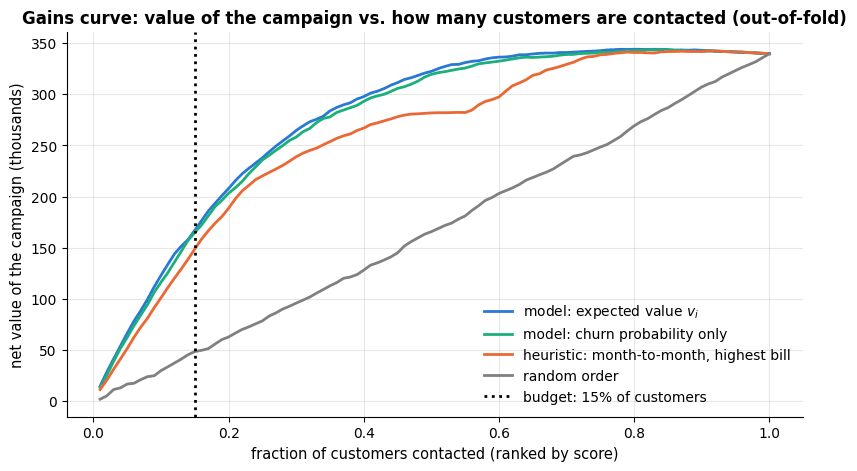

model: expected value $v_i$                at 15%: value   167048   precision 0.835
model: churn probability only              at 15%: value   164969   precision 0.858
heuristic: month-to-month, highest bill    at 15%: value   148419   precision 0.725
random order                               at 15%: value    48397   precision 0.307


In [16]:
def gains_curve(y_true, monthly_charges, ranking_scores, fractions):
    order = np.argsort(-np.asarray(ranking_scores))
    n = len(order)
    out = []
    for f in fractions:
        contacted = np.zeros(n, dtype=bool)
        contacted[order[: int(np.ceil(f * n))]] = True
        out.append(realised_value(y_true, monthly_charges, contacted))
    return np.array(out)

mc_trval = X_trval["monthly_charges"].fillna(X_trval["monthly_charges"].median()).to_numpy()
fractions = np.linspace(0.01, 1.0, 100)
rankings = {"model: expected value $v_i$": expected_value(p_oof, mc_trval),
            "model: churn probability only": p_oof,
            "heuristic: month-to-month, highest bill": heuristic_scores(X_trval).to_numpy(),
            "random order": rng.random(len(y_trval))}
fig, ax = plt.subplots(figsize=(9.5, 5))
for (name, scores_), color in zip(rankings.items(), [PALETTE[0], PALETTE[2], PALETTE[1], "gray"]):
    ax.plot(fractions, gains_curve(y_trval, mc_trval, scores_, fractions) / 1000, label=name, color=color)
ax.axvline(BUDGET, color="black", ls=":", label=f"budget: {BUDGET:.0%} of customers")
ax.set_xlabel("fraction of customers contacted (ranked by score)")
ax.set_ylabel("net value of the campaign (thousands)")
ax.set_title("Gains curve: value of the campaign vs. how many customers are contacted (out-of-fold)")
ax.legend()
plt.show()
for name, scores_ in rankings.items():
    m = top_k_mask(scores_)
    print(f"{name:42s} at {BUDGET:.0%}: value {realised_value(y_trval, mc_trval, m):8.0f}   precision {y_trval[m].mean():.3f}")

Ranking by expected value rather than by probability alone moves high-bill customers up
the list: it adds about 2 000 to the campaign's value while *lowering* precision from
0.86 to 0.84 — exactly the trade it is supposed to make, since a churner paying 100 a
month is worth more than two churners paying 20. The curve also shows *where the
budget should be*: the campaign's net value keeps rising well past 15 %, so the report
should tell the team what a larger budget would buy (exercise 1). The deployed decision
rule is therefore: *score every customer, compute $v_i$, contact the top 15 %*. We also
record the value threshold this corresponds to in the training data, so that the
scoring script can flag customers by a fixed rule when the campaign size is fixed in
advance.

In [17]:
v_oof = expected_value(p_oof, mc_trval)
V_THRESHOLD = float(np.quantile(v_oof, 1 - BUDGET))
print(f"contact rule: expected value v_i >= {V_THRESHOLD:.1f}  (top {BUDGET:.0%} of the training customers)")

contact rule: expected value v_i >= 221.2  (top 15% of the training customers)


Two curves make the budget discussion concrete. On the left, the campaign's value as a
function of the cut-off on $v_i$: the unconstrained optimum is at $v_i = 0$ (contact
everyone for whom a call pays off in expectation), the budget forces us far to the right of
it, and the distance between the two lines is what the budget costs. On the right, the
fraction of customers that each cut-off contacts — the map between the two languages the
meeting will use ("a threshold of 220" and "15 % of the base").

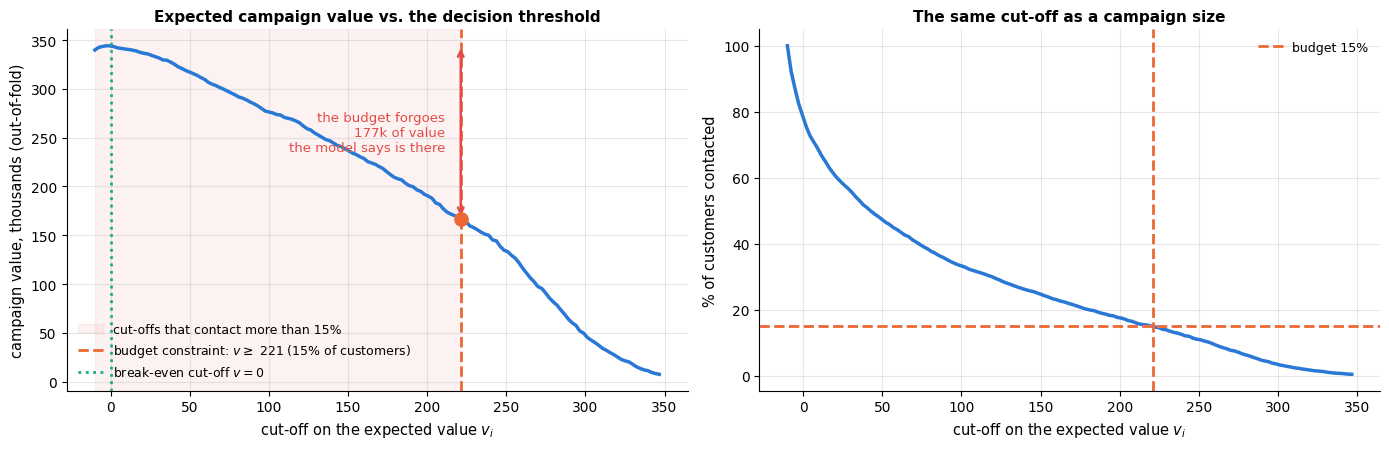

value at the budget cut-off: 167,048; at the break-even cut-off v = 0 (78% of customers): 344,246


In [18]:
value_grid = np.linspace(-C_CONTACT, float(np.quantile(v_oof, 0.995)), 150)
campaign_value = np.array([realised_value(y_trval, mc_trval, v_oof >= t) for t in value_grid])
contacted_frac = np.array([float((v_oof >= t).mean()) for t in value_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharex=True)
value_at_budget = realised_value(y_trval, mc_trval, v_oof >= V_THRESHOLD) / 1000
value_at_zero = realised_value(y_trval, mc_trval, v_oof >= 0) / 1000
axes[0].plot(value_grid, campaign_value / 1000, lw=2.5, color=PALETTE[0])
axes[0].axvspan(value_grid[0], V_THRESHOLD, color=PALETTE[7], alpha=0.07,
                label=f"cut-offs that contact more than {BUDGET:.0%}")
axes[0].axvline(V_THRESHOLD, color=PALETTE[1], ls="--", lw=2,
                label=f"budget constraint: $v \\geq$ {V_THRESHOLD:.0f} ({BUDGET:.0%} of customers)")
axes[0].axvline(0.0, color=PALETTE[2], ls=":", lw=2, label="break-even cut-off $v = 0$")
axes[0].scatter([V_THRESHOLD], [value_at_budget], color=PALETTE[1], s=90, zorder=5)
axes[0].annotate("", xy=(V_THRESHOLD, value_at_zero), xytext=(V_THRESHOLD, value_at_budget),
                 arrowprops=dict(arrowstyle="<->", color=PALETTE[7], lw=1.8))
axes[0].text(V_THRESHOLD - 10, (value_at_zero + value_at_budget) / 2,
             f"the budget forgoes\n{value_at_zero - value_at_budget:.0f}k of value\nthe model says is there",
             ha="right", va="center", fontsize=9.5, color=PALETTE[7])
axes[0].set_ylabel("campaign value, thousands (out-of-fold)")
axes[0].set_xlabel("cut-off on the expected value $v_i$")
axes[0].set_title("Expected campaign value vs. the decision threshold", fontsize=11)
axes[0].legend(fontsize=9, loc="lower left")

axes[1].plot(value_grid, contacted_frac * 100, lw=2.5, color=PALETTE[0])
axes[1].axhline(BUDGET * 100, color=PALETTE[1], ls="--", lw=2, label=f"budget {BUDGET:.0%}")
axes[1].axvline(V_THRESHOLD, color=PALETTE[1], ls="--", lw=2)
axes[1].set_xlabel("cut-off on the expected value $v_i$")
axes[1].set_ylabel("% of customers contacted")
axes[1].set_title("The same cut-off as a campaign size", fontsize=11)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"value at the budget cut-off: {realised_value(y_trval, mc_trval, v_oof >= V_THRESHOLD):,.0f}; "
      f"at the break-even cut-off v = 0 ({(v_oof >= 0).mean():.0%} of customers): "
      f"{realised_value(y_trval, mc_trval, v_oof >= 0):,.0f}")

The retention team also thinks in terms of *how many of the churners we reach*. The
cumulative-gain curve answers that directly — contact the top $x$ % of the ranking and you
reach $y$ % of everyone who would have left — and the lift curve rescales it by what random
calling would achieve.

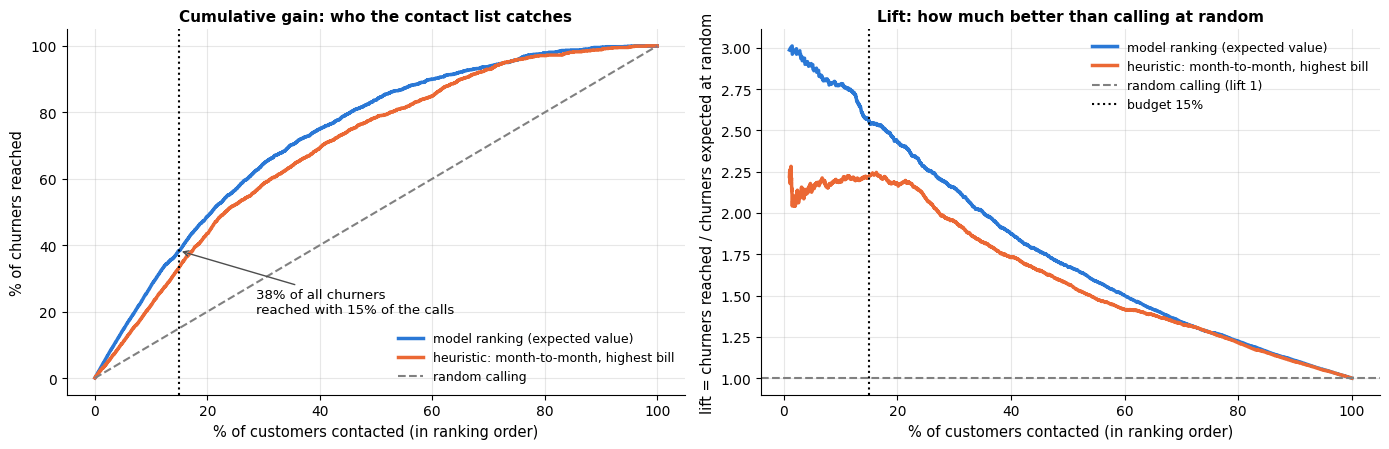

In [19]:
order = np.argsort(-v_oof)
order_heur = np.argsort(-heuristic_scores(X_trval).to_numpy())
frac_contacted = np.arange(1, len(y_trval) + 1) / len(y_trval)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for (label, idx), color in zip([("model ranking (expected value)", order),
                                ("heuristic: month-to-month, highest bill", order_heur)],
                               [PALETTE[0], PALETTE[1]]):
    captured = np.cumsum(y_trval[idx]) / y_trval.sum()
    axes[0].plot(frac_contacted * 100, captured * 100, lw=2.5, color=color, label=label)
    axes[1].plot(frac_contacted[39:] * 100, captured[39:] / frac_contacted[39:], lw=2.5, color=color, label=label)
    if label.startswith("model"):
        at_budget = captured[int(BUDGET * len(y_trval)) - 1]
        axes[0].annotate(f"{at_budget:.0%} of all churners\nreached with {BUDGET:.0%} of the calls",
                         xy=(BUDGET * 100, at_budget * 100), xytext=(55, -45), textcoords="offset points",
                         fontsize=9.5, arrowprops=dict(arrowstyle="->", color="0.3"))
axes[0].plot([0, 100], [0, 100], color="gray", ls="--", lw=1.5, label="random calling")
axes[0].axvline(BUDGET * 100, color="black", ls=":", lw=1.5)
axes[0].set_xlabel("% of customers contacted (in ranking order)")
axes[0].set_ylabel("% of churners reached")
axes[0].set_title("Cumulative gain: who the contact list catches", fontsize=11)
axes[0].legend(fontsize=9, loc="lower right")

axes[1].axhline(1.0, color="gray", ls="--", lw=1.5, label="random calling (lift 1)")
axes[1].axvline(BUDGET * 100, color="black", ls=":", lw=1.5, label=f"budget {BUDGET:.0%}")
axes[1].set_xlabel("% of customers contacted (in ranking order)")
axes[1].set_ylabel("lift = churners reached / churners expected at random")
axes[1].set_title("Lift: how much better than calling at random", fontsize=11)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Held-out evaluation with uncertainty

Now — once — the test set. Two kinds of numbers go into the report: model-quality
metrics, and the business metric of the actual decision rule, each with a **bootstrap
confidence interval** (Efron, 1979; notebook 2): resample the test customers with
replacement 200 times, recompute every metric, and take the 2.5 % and 97.5 % percentiles.
For the comparison with the heuristic we bootstrap the *difference* on the same
resamples (a paired comparison), which is much tighter than comparing two separate
intervals.

In [20]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

p_test = final_model.predict_proba(X_test)[:, 1]
mc_test = X_test["monthly_charges"].fillna(X_trval["monthly_charges"].median()).to_numpy()
v_test = expected_value(p_test, mc_test)
heur_test = heuristic_scores(X_test).to_numpy()

def all_metrics(idx):
    yt, pt, vt, ht, mt = y_test[idx], p_test[idx], v_test[idx], heur_test[idx], mc_test[idx]
    model_value = realised_value(yt, mt, top_k_mask(vt))
    heur_value = realised_value(yt, mt, top_k_mask(ht))
    return {"ROC AUC": roc_auc_score(yt, pt), "avg precision": average_precision_score(yt, pt),
            "log loss": log_loss(yt, pt), "precision@15%": precision_at_budget(yt, vt),
            "campaign value (model)": model_value, "campaign value (heuristic)": heur_value,
            "value gain over heuristic": model_value - heur_value}

point = all_metrics(np.arange(len(y_test)))
boot = pd.DataFrame([all_metrics(rng.integers(0, len(y_test), len(y_test))) for _ in range(200)])
ci = boot.quantile([0.025, 0.975]).T
report = pd.DataFrame({"test estimate": pd.Series(point), "95% CI low": ci[0.025], "95% CI high": ci[0.975]})
test_report = report.round(3)
test_report

,test estimate,95% CI low,95% CI high
ROC AUC,0.826,0.801,0.849
avg precision,0.712,0.670,0.755
log loss,0.472,0.440,0.508
precision@15%,0.787,0.726,0.860
campaign value (model),39199.080,35731.156,43352.162
campaign value (heuristic),35441.256,31038.350,38942.749
value gain over heuristic,3757.824,1276.664,7212.740


A confidence interval printed as two numbers is easy to ignore; the bootstrap
*distributions* are harder to ignore, and they show the shape of the uncertainty — in
particular that the paired gain over the heuristic, while clearly positive, is skewed to
the right and has a lower bound about a third of the point estimate. "The model is worth
roughly 3 800 a month, and we would not be surprised by 1 300" is a more useful sentence
than "the gain is significant".

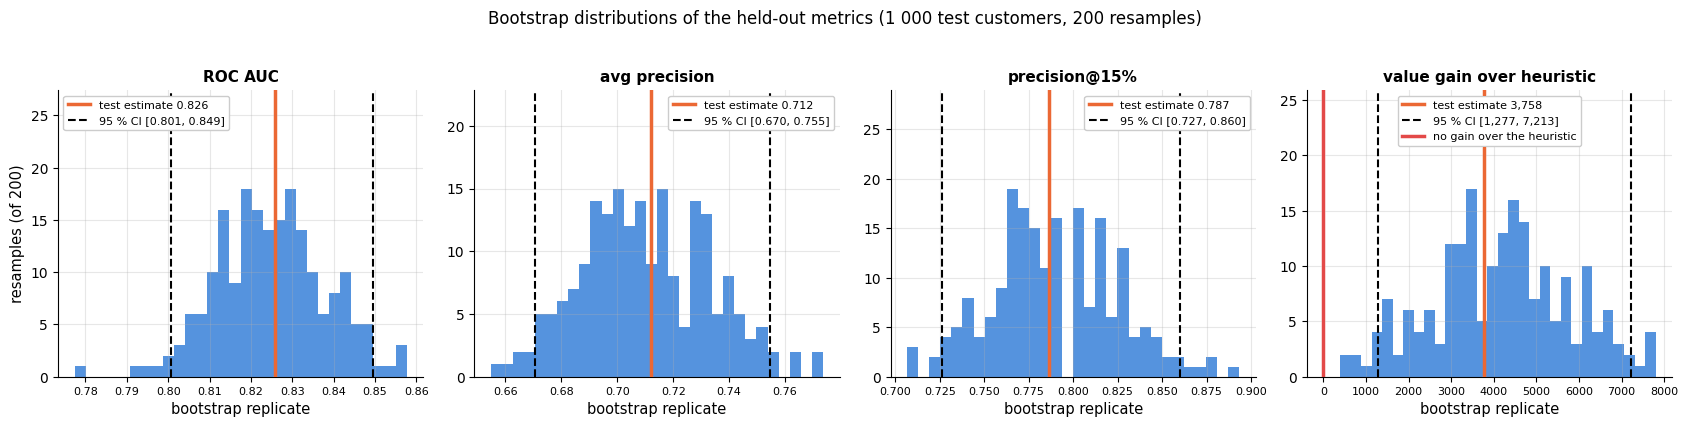

In [21]:
boot_metrics = ["ROC AUC", "avg precision", "precision@15%", "value gain over heuristic"]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.1))
for ax, metric in zip(axes, boot_metrics):
    fmt = (lambda v: f"{v:,.0f}") if "value" in metric else (lambda v: f"{v:.3f}")
    ax.hist(boot[metric], bins=30, color=PALETTE[0], alpha=0.8)
    ax.axvline(point[metric], color=PALETTE[1], lw=2.5, label=f"test estimate {fmt(point[metric])}")
    ax.axvline(ci.loc[metric, 0.025], color="black", ls="--", lw=1.5,
               label=f"95 % CI [{fmt(ci.loc[metric, 0.025])}, {fmt(ci.loc[metric, 0.975])}]")
    ax.axvline(ci.loc[metric, 0.975], color="black", ls="--", lw=1.5)
    if metric == "value gain over heuristic":
        ax.axvline(0, color=PALETTE[7], lw=2.5, label="no gain over the heuristic")
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("bootstrap replicate")
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.45)
    ax.legend(fontsize=8, frameon=True, framealpha=1.0)
axes[0].set_ylabel("resamples (of 200)")
fig.suptitle("Bootstrap distributions of the held-out metrics (1 000 test customers, 200 resamples)", y=1.03)
plt.tight_layout()
plt.show()

The two threshold-free curves complete the picture: the ROC curve for the ranking as a
whole, the precision–recall curve because the positives are the minority and the campaign
lives at the top of the ranking. The operating point of the deployed rule — the 15 % of
customers with the highest expected value — is marked on both.

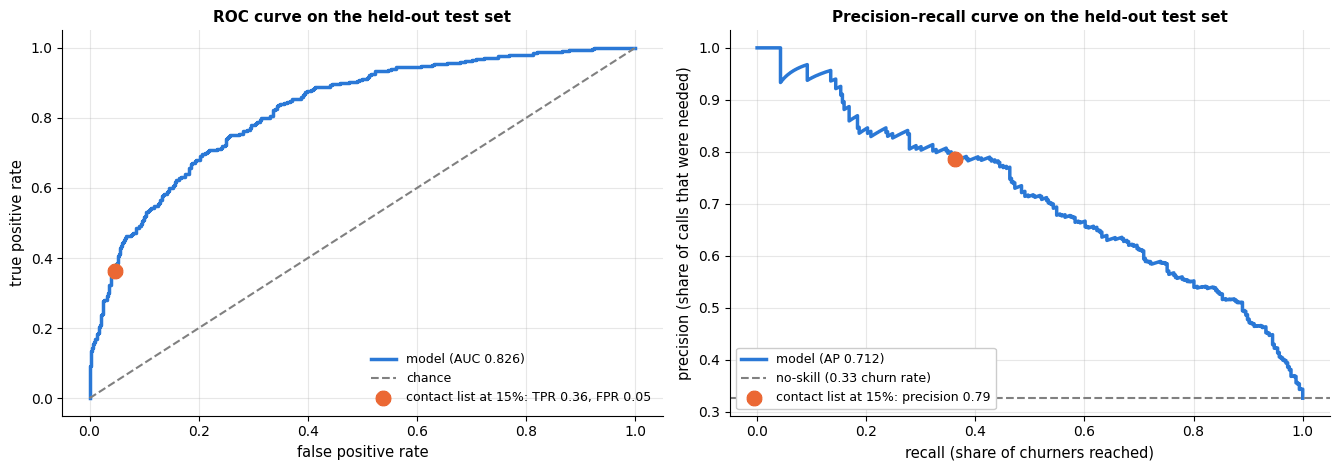

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve

mask_budget = top_k_mask(v_test)
tp = np.sum(mask_budget & (y_test == 1))
op_tpr = tp / np.sum(y_test == 1)
op_fpr = np.sum(mask_budget & (y_test == 0)) / np.sum(y_test == 0)
op_precision = y_test[mask_budget].mean()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
fpr, tpr, _ = roc_curve(y_test, p_test)
axes[0].plot(fpr, tpr, lw=2.5, color=PALETTE[0], label=f"model (AUC {point['ROC AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls="--", lw=1.5, label="chance")
axes[0].scatter([op_fpr], [op_tpr], color=PALETTE[1], s=110, zorder=5,
                label=f"contact list at {BUDGET:.0%}: TPR {op_tpr:.2f}, FPR {op_fpr:.2f}")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curve on the held-out test set", fontsize=11)
axes[0].legend(fontsize=9, loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, p_test)
axes[1].plot(rec, prec, lw=2.5, color=PALETTE[0], label=f"model (AP {point['avg precision']:.3f})")
axes[1].axhline(y_test.mean(), color="gray", ls="--", lw=1.5, label=f"no-skill ({y_test.mean():.2f} churn rate)")
axes[1].scatter([op_tpr], [op_precision], color=PALETTE[1], s=110, zorder=5,
                label=f"contact list at {BUDGET:.0%}: precision {op_precision:.2f}")
axes[1].set_xlabel("recall (share of churners reached)")
axes[1].set_ylabel("precision (share of calls that were needed)")
axes[1].set_title("Precision–recall curve on the held-out test set", fontsize=11)
axes[1].legend(fontsize=9, loc="lower left", frameon=True, framealpha=1.0)
plt.tight_layout()
plt.show()

The test estimates come out a little *below* the cross-validated ones of section 5 (ROC
AUC 0.826 against 0.857, average precision 0.712 against 0.763) — a gap of roughly the
width of the bootstrap interval. Some of it is the mild optimism of a score computed on
the same data the search was run on, some of it is that 1 000 customers are themselves a
small sample; either way it is the reason the test set exists, and the *test* number is
the one that goes in the report. What survives the move is the comparison: the paired
interval for the gain over the heuristic excludes zero, so the model's advantage is real,
if modest, and *that* is what the report should say, with the interval.

## 8. Error analysis by segment

An aggregate metric hides where the model fails. We split the test customers along
business-relevant lines and compute, per segment, the churn rate, the model's ranking
quality (AUC) and — most relevant for the campaign — the **recall of the contact list**:
what fraction of that segment's churners are on it.

In [23]:
contacted_test = top_k_mask(v_test)
seg_df = X_test.assign(y=y_test, p=p_test, contacted=contacted_test,
                       tenure_bucket=pd.cut(X_test["tenure_months"], bins=[-1, 5, 12, 24, 48, 72],
                                            labels=["0-5", "6-12", "13-24", "25-48", "49-72"]))

def segment_table(df, column):
    rows = []
    for value, d in df.groupby(column, observed=True):
        churners = d[d["y"] == 1]
        rows.append({column: str(value), "n": len(d), "churn rate": d["y"].mean(),
                     "AUC": roc_auc_score(d["y"], d["p"]) if d["y"].nunique() == 2 else np.nan,
                     "contacted": d["contacted"].mean(),
                     "recall of contact list": churners["contacted"].mean() if len(churners) else np.nan,
                     "precision of contact list": d.loc[d["contacted"], "y"].mean() if d["contacted"].any() else np.nan})
    return pd.DataFrame(rows).set_index(column)

segment_tables = {column: segment_table(seg_df, column) for column in ["contract", "tenure_bucket", "internet_service"]}
for column, table in segment_tables.items():
    display(table.round(3))

,n,churn rate,AUC,contacted,recall of contact list,precision of contact list
contract,,,,,,
Month-to-month,582,0.447,0.771,0.241,0.423,0.786
One year,231,0.190,0.846,0.043,0.182,0.800
Two year,187,0.118,0.792,0.000,0.000,NaN


,n,churn rate,AUC,contacted,recall of contact list,precision of contact list
tenure_bucket,,,,,,
0-5,86,0.628,0.727,0.372,0.519,0.875
6-12,182,0.473,0.784,0.242,0.407,0.795
13-24,272,0.404,0.807,0.199,0.391,0.796
25-48,279,0.208,0.752,0.068,0.207,0.632
49-72,181,0.099,0.785,0.006,0.000,0.000


,n,churn rate,AUC,contacted,recall of contact list,precision of contact list
internet_service,,,,,,
DSL,409,0.222,0.730,0.002,0.011,1.000
Fiber optic,414,0.512,0.806,0.360,0.552,0.785
No,177,0.130,0.829,0.000,0.000,NaN


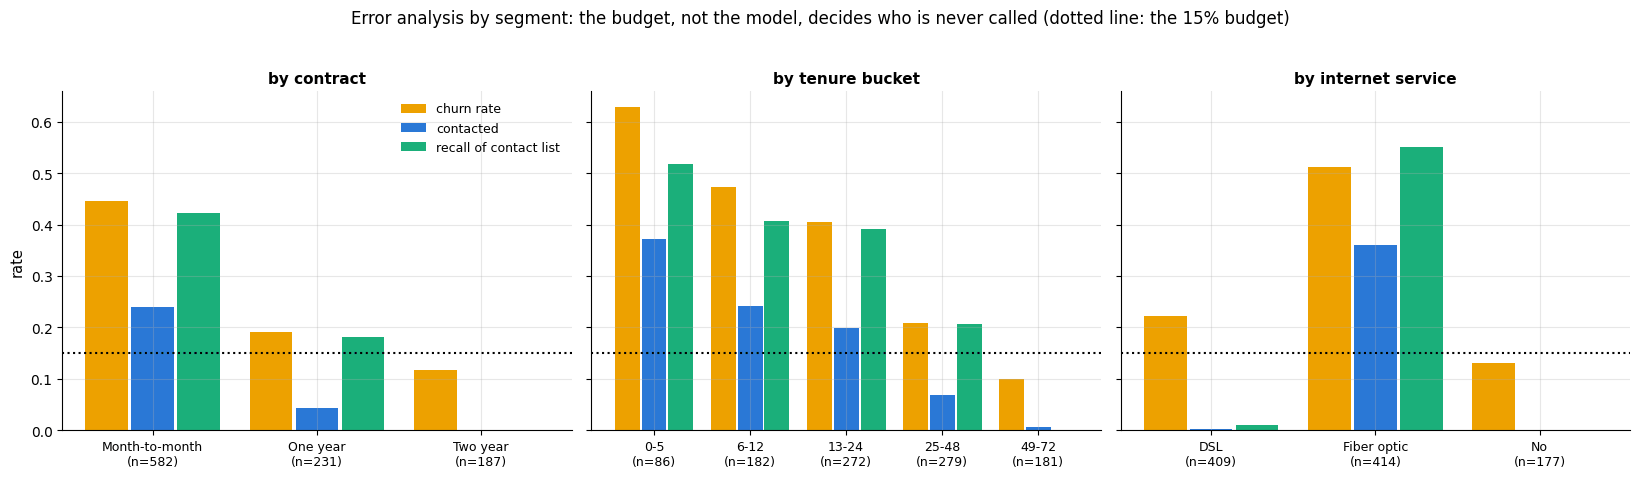

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6), sharey=True)
bar_metrics = ["churn rate", "contacted", "recall of contact list"]
for ax, (column, table) in zip(axes, segment_tables.items()):
    x = np.arange(len(table))
    for k, (metric, color) in enumerate(zip(bar_metrics, [PALETTE[3], PALETTE[0], PALETTE[2]])):
        ax.bar(x + (k - 1) * 0.28, table[metric].to_numpy(dtype=float), width=0.26, color=color, label=metric)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\n(n={int(n)})" for i, n in zip(table.index, table["n"])], fontsize=9)
    ax.set_title(f"by {column.replace('_', ' ')}", fontsize=11)
    ax.axhline(BUDGET, color="black", ls=":", lw=1.5)
axes[0].set_ylabel("rate")
axes[0].legend(fontsize=9, loc="upper right")
fig.suptitle("Error analysis by segment: the budget, not the model, decides who is never called "
             f"(dotted line: the {BUDGET:.0%} budget)", y=1.03)
plt.tight_layout()
plt.show()

The pattern is instructive: the contact list is almost entirely month-to-month customers
with fibre-optic internet, which is where churn is. Recall is 0.42 there, 0.18 for one-year
contracts and exactly 0 for two-year ones — the few churners on long contracts are
invisible to a 15 % budget. The same holds by internet service: DSL customers churn at
22 % but only 0.2 % of them are called — a single customer in a list of 150. The AUC
*within* the two-year segment (0.79) shows
that the model still ranks those customers sensibly; it is the budget, not the model, that
leaves them out. Whether that is acceptable is a business question the report must raise
(long-contract churners are rare, but each is worth a lot of months).

## 9. Interpretability: global and local explanations

The retention team will ask *why* a customer is on the list, and the compliance team
will ask *what the model uses*. Notebook 17 gives the tools; we use three.

**Permutation importance** (Fisher, Rudin & Dominici, 2019) on the test set: how much does
average precision drop when a column is shuffled? **Partial dependence** (Friedman,
2001) for the most important numeric features: how does the predicted probability change
as one feature varies, on average? And a **local explanation**: for a customer on the
contact list, how much would the prediction change if each feature took a typical value?

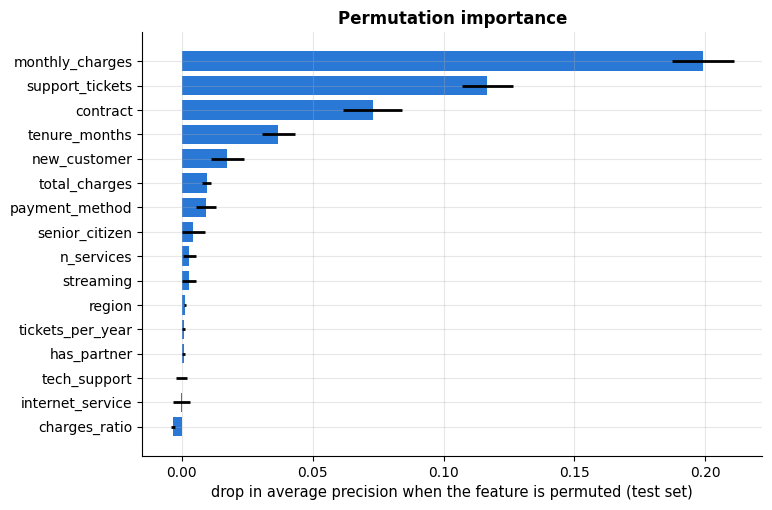

In [25]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

pi = permutation_importance(final_model, X_test, y_test, scoring="average_precision", n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=1)
importance = pd.DataFrame({"importance": pi.importances_mean, "std": pi.importances_std}, index=X_test.columns) \
    .sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importance.index, importance["importance"], xerr=importance["std"], color=PALETTE[0])
ax.set_xlabel("drop in average precision when the feature is permuted (test set)")
ax.set_title("Permutation importance")
plt.show()

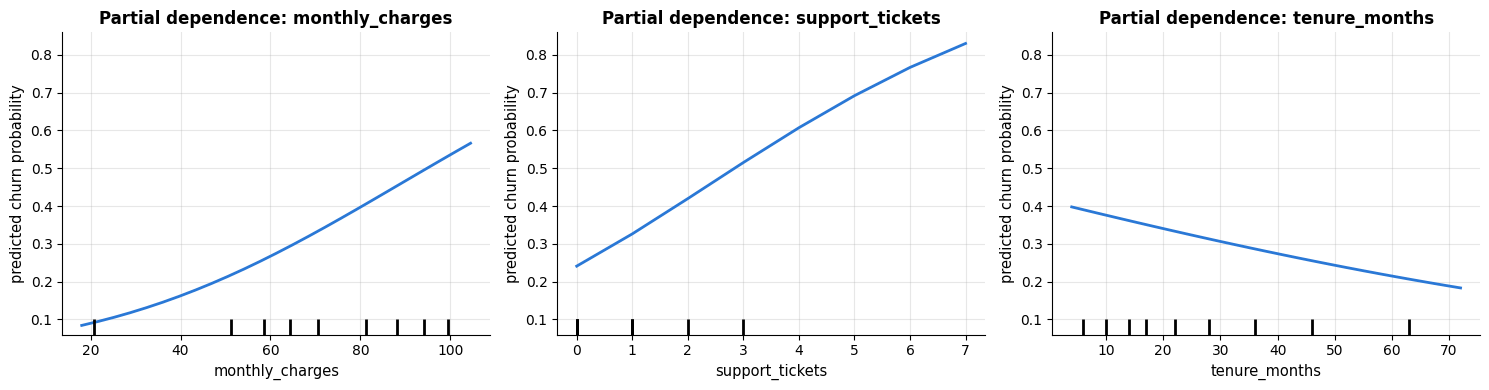

In [26]:
top_numeric = [f for f in importance.index[::-1] if f in NUMERIC][:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(final_model, X_test, features=top_numeric, kind="average",
                                        grid_resolution=25, ax=axes)
for ax, f in zip(axes, top_numeric):
    ax.set_title(f"Partial dependence: {f}")
    ax.set_ylabel("predicted churn probability")
plt.tight_layout()
plt.show()

The important features are the ones the EDA pointed to (charges, tickets, contract,
tenure), and the partial-dependence shapes are monotone in the directions a manager would
expect — a cheap but valuable sanity check that the model learned the business and not an
artefact. The local explanation below replaces each feature of one customer by the
training-set median (numeric) or mode (categorical) and records the change in predicted
probability: a *what-if* attribution, simple enough to explain on the phone. (SHAP values,
notebook 17, are the principled version of the same idea.)

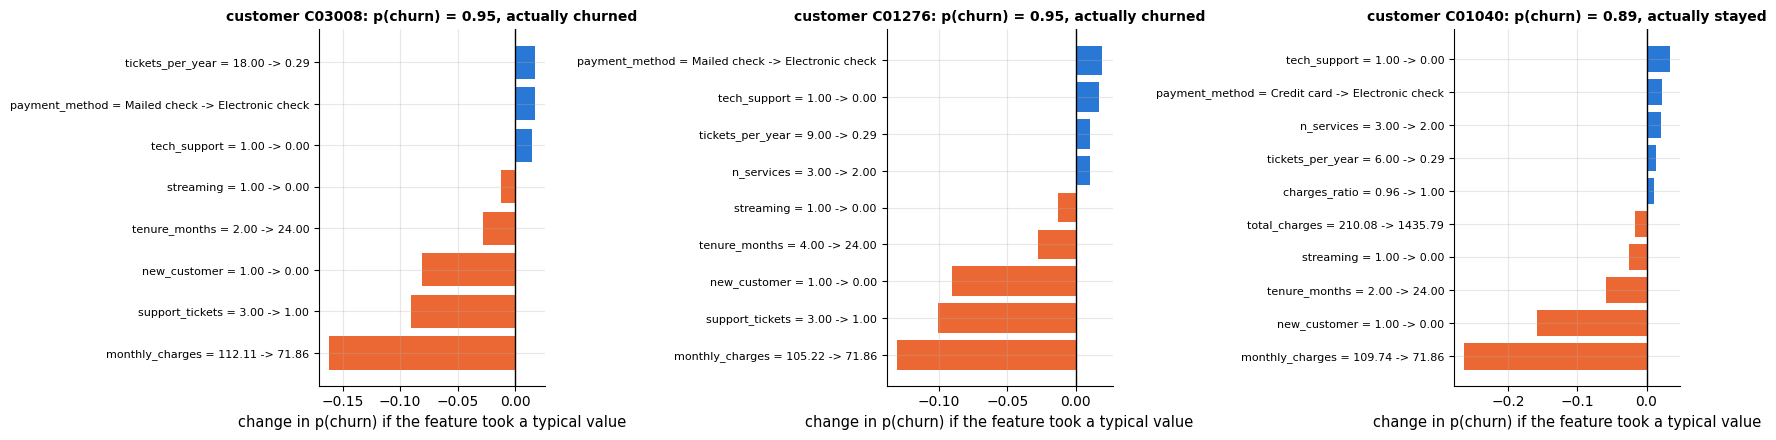

In [27]:
typical = {c: X_trval[c].median() for c in NUMERIC} | {c: X_trval[c].mode()[0] for c in CATEGORICAL}

def what_if_explanation(model, x_row):
    base_p = model.predict_proba(x_row.to_frame().T)[0, 1]
    deltas = {}
    for col, typ in typical.items():
        if x_row[col] == typ:
            continue
        x_alt = x_row.copy()
        x_alt[col] = typ
        deltas[f"{col} = {x_row[col]:.2f} -> {typ:.2f}" if col in NUMERIC else f"{col} = {x_row[col]} -> {typ}"] = \
            model.predict_proba(x_alt.to_frame().T)[0, 1] - base_p
    return base_p, pd.Series(deltas).sort_values()

top_customers = np.argsort(-v_test)[:3]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, i in zip(axes, top_customers):
    base_p, deltas = what_if_explanation(final_model, X_test.iloc[i])
    deltas = deltas[deltas.abs() > 0.01]
    ax.barh(deltas.index, deltas.values, color=[PALETTE[1] if v < 0 else PALETTE[0] for v in deltas.values])
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"customer {test_df['customer_id'].iloc[i]}: p(churn) = {base_p:.2f}, "
                 f"actually {'churned' if y_test[i] else 'stayed'}", fontsize=10)
    ax.set_xlabel("change in p(churn) if the feature took a typical value")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 10. Fairness check

The retention offer is a *benefit*, so the fairness question of notebook 19 is: do
comparable customers in different groups have the same chance of receiving it? We look
at the selection rate (who gets contacted), the true positive rate (which churners get
contacted) and the false positive rate, by `senior_citizen` and by `region`, at the
deployed budget.

by senior_citizen:


,n,churn rate,selection rate,TPR,FPR,PPV
0.0,831.0,0.321,0.152,0.367,0.050,0.778
1.0,169.0,0.349,0.142,0.339,0.036,0.833


by region:


,n,churn rate,selection rate,TPR,FPR,PPV
East,283.0,0.353,0.152,0.330,0.055,0.767
North,256.0,0.312,0.148,0.388,0.040,0.816
South,215.0,0.353,0.158,0.395,0.029,0.882
West,246.0,0.285,0.142,0.343,0.062,0.686


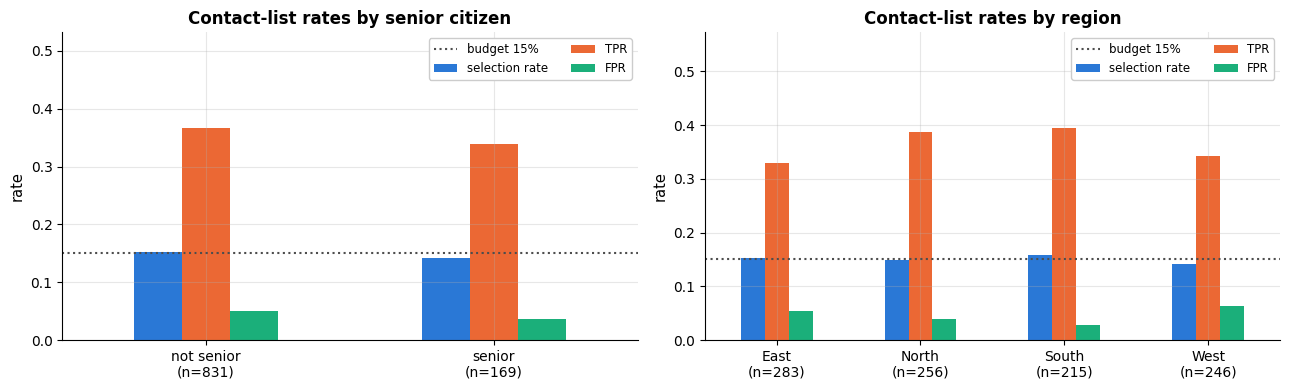

In [28]:
def group_rates(y_true, y_pred, group):
    """Per-group selection rate, TPR, FPR and PPV (from notebook 19)."""
    y_true, y_pred, group = (np.asarray(a) for a in (y_true, y_pred, group))
    rows = {}
    for g in np.unique(group):
        m = group == g
        yt, yp = y_true[m], y_pred[m].astype(int)
        tp, fp = np.sum((yt == 1) & (yp == 1)), np.sum((yt == 0) & (yp == 1))
        fn, tn = np.sum((yt == 1) & (yp == 0)), np.sum((yt == 0) & (yp == 0))
        rows[g] = {"n": int(m.sum()), "churn rate": yt.mean(), "selection rate": yp.mean(),
                   "TPR": tp / (tp + fn), "FPR": fp / (fp + tn), "PPV": tp / max(tp + fp, 1)}
    return pd.DataFrame(rows).T

fairness_tables = {}
for attr in ["senior_citizen", "region"]:
    fairness_tables[attr] = group_rates(y_test, contacted_test, X_test[attr].astype(str))
    print(f"by {attr}:")
    display(fairness_tables[attr].round(3))

GROUP_LABELS = {"senior_citizen": {"0.0": "not senior", "1.0": "senior"}}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, attr in zip(axes, fairness_tables):
    table = fairness_tables[attr]
    table[["selection rate", "TPR", "FPR"]].plot.bar(ax=ax, rot=0, color=PALETTE[:3])
    labels = GROUP_LABELS.get(attr, {})
    ax.set_xticklabels([f"{labels.get(str(g), str(g))}\n(n={int(table.loc[g, 'n'])})" for g in table.index])
    ax.set_xlabel("")
    ax.axhline(BUDGET, color="0.3", ls=":", lw=1.5, label=f"budget {BUDGET:.0%}")
    ax.set_ylim(0, float(table[["selection rate", "TPR", "FPR"]].to_numpy(dtype=float).max()) * 1.45)
    ax.set_title(f"Contact-list rates by {attr.replace('_', ' ')}")
    ax.set_ylabel("rate")
    ax.legend(loc="upper right", fontsize=8.5, frameon=True, framealpha=1.0, ncol=2)
plt.tight_layout()
plt.show()

Senior citizens churn slightly *more* often than other customers (0.35 against 0.32) and
are contacted slightly *less* often (0.142 against 0.152); their churners are reached at a
marginally lower rate as well (TPR 0.34 against 0.37). Before reading anything into that,
note the sample: 169 seniors, so a selection rate of 0.14 carries a standard error of
about 0.027. A one-point gap is indistinguishable from noise, and the honest statement is
that the offer reaches the two groups at comparable rates — equal opportunity, in the
vocabulary of notebook 19 — not that it favours either. Across regions, whose churn rates
are alike, selection rates and error rates are alike too, with the same caveat about
sample size. Two things belong in the report regardless: `senior_citizen` is *used* as a
feature (the model may legitimately do so for a benefit, but that is a policy decision to
record), and a gap of this size should be re-measured on the full customer base — and
monitored monthly — before anyone acts on it.

## 11. Packaging: persistence, model card and batch scoring

Notebook 18 gives the reasons; here is the minimal complete version. We save the fitted
pipeline with `joblib`, and next to it a JSON record of *everything needed to trust the
file later*: library versions, a hash of the training data, the feature list, the CV and
test metrics, the decision rule and its economic assumptions.

In [29]:
import sklearn
import joblib

data_hash = hashlib.sha256(pd.util.hash_pandas_object(train_df, index=False).to_numpy().tobytes()).hexdigest()[:12]
metadata = {
    "model_name": "capstone-churn-retention",
    "version": "1.0.0",
    "created": pd.Timestamp.now().isoformat(timespec="seconds"),
    "estimator": FINAL_NAME,
    "best_params": {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in searches[FINAL_NAME].best_params_.items()},
    "sklearn_version": sklearn.__version__, "pandas_version": pd.__version__, "numpy_version": np.__version__,
    "training_data": {"source": "customer_churn.csv (cleaned)", "rows": int(len(train_df)), "sha256_prefix": data_hash},
    "features": {"numeric": NUMERIC, "categorical": CATEGORICAL, "engineering": "add_features() v1"},
    "cv_metrics": {"avg_precision": round(float(scores[FINAL_NAME]), 4), "std_error": round(float(std_errs[FINAL_NAME]), 4)},
    "test_metrics": {k: round(float(v), 4) for k, v in point.items()},
    "decision_rule": {"budget_fraction": BUDGET, "value_threshold": round(V_THRESHOLD, 2),
                      "assumptions": {"retention_success": S_RETAIN, "horizon_months": HORIZON, "contact_cost": C_CONTACT}},
}
joblib.dump(final_model, ARTIFACTS / "capstone_churn_model.joblib")
(ARTIFACTS / "capstone_churn_model.json").write_text(json.dumps(metadata, indent=2))
print(f"saved {ARTIFACTS / 'capstone_churn_model.joblib'} ({(ARTIFACTS / 'capstone_churn_model.joblib').stat().st_size / 1024:.0f} KB)")
print(json.dumps({k: metadata[k] for k in ["estimator", "training_data", "cv_metrics", "decision_rule"]}, indent=2))

saved artifacts/capstone_churn_model.joblib (5 KB)
{
  "estimator": "logistic regression (tuned)",
  "training_data": {
    "source": "customer_churn.csv (cleaned)",
    "rows": 4000,
    "sha256_prefix": "a63cb2c20a34"
  },
  "cv_metrics": {
    "avg_precision": 0.7634,
    "std_error": 0.0092
  },
  "decision_rule": {
    "budget_fraction": 0.15,
    "value_threshold": 221.23,
    "assumptions": {
      "retention_success": 0.3,
      "horizon_months": 12,
      "contact_cost": 10.0
    }
  }
}


The **model card** (Mitchell et al., 2019) is the human-readable companion: what the model
is for, what it must not be used for, how it was evaluated — *disaggregated* — and what
its known limitations are. We generate it from the numbers above so that it cannot drift
from the model.

In [30]:
srs = fairness_tables["senior_citizen"]
model_card = f"""# Model card — churn retention ranking model (v{metadata['version']})

## Intended use
Rank customers for a monthly retention campaign that can contact {BUDGET:.0%} of the customer base.
Output: churn probability and expected net value of a contact. Not intended for pricing, credit or
any decision that withholds a service from a customer.

## Model
{FINAL_NAME}, scikit-learn {sklearn.__version__}, trained {metadata['created'][:10]} on {len(train_df)} customers
(data hash {data_hash}). Features: {len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical (see JSON metadata).

## Performance (held-out test set, n = {len(y_test)}, 95% bootstrap CIs)
| metric | estimate | CI |
|---|---|---|
""" + "\n".join(f"| {k} | {report.loc[k, 'test estimate']:.3f} | [{report.loc[k, '95% CI low']:.3f}, {report.loc[k, '95% CI high']:.3f}] |"
                for k in ["ROC AUC", "avg precision", "precision@15%", "value gain over heuristic"]) + f"""

## Disaggregated evaluation (contact list at {BUDGET:.0%} budget)
| senior citizen | n | churn rate | selection rate | TPR | FPR |
|---|---|---|---|---|---|
""" + "\n".join(f"| {g} | {int(r['n'])} | {r['churn rate']:.3f} | {r['selection rate']:.3f} | {r['TPR']:.3f} | {r['FPR']:.3f} |"
                for g, r in srs.iterrows()) + f"""

## Decision rule and assumptions
Contact the top {BUDGET:.0%} by expected value v = p * {S_RETAIN} * {HORIZON} * monthly_charges - {C_CONTACT:.0f}.
The retention-success probability ({S_RETAIN}) and horizon ({HORIZON} months) are assumptions, not measurements;
a randomised control group in the first campaigns should replace them.

## Limitations
- Trained on one snapshot; performance on customers whose behaviour changes (new products, price changes) is unknown.
- Customers on long contracts are rarely on the list because of the budget, not the model.
- `senior_citizen` is used as a feature; the offer is a benefit, but this should be reviewed with legal/compliance.
- The value model ignores customers who would have stayed without the offer (see uplift modelling).

## Monitoring
Input drift (PSI on monthly_charges, tenure_months, contract mix), score distribution, realised churn of contacted vs
not-contacted customers (labels arrive with one month delay), selection and true-positive rates by senior_citizen and region.
"""
(ARTIFACTS / "capstone_model_card.md").write_text(model_card)
print(model_card[:1200] + "\n...")

# Model card — churn retention ranking model (v1.0.0)

## Intended use
Rank customers for a monthly retention campaign that can contact 15% of the customer base.
Output: churn probability and expected net value of a contact. Not intended for pricing, credit or
any decision that withholds a service from a customer.

## Model
logistic regression (tuned), scikit-learn 1.8.0, trained 2026-09-19 on 4000 customers
(data hash a63cb2c20a34). Features: 12 numeric, 4 categorical (see JSON metadata).

## Performance (held-out test set, n = 1000, 95% bootstrap CIs)
| metric | estimate | CI |
|---|---|---|
| ROC AUC | 0.826 | [0.801, 0.849] |
| avg precision | 0.712 | [0.670, 0.755] |
| precision@15% | 0.787 | [0.727, 0.860] |
| value gain over heuristic | 3757.824 | [1276.664, 7212.740] |

## Disaggregated evaluation (contact list at 15% budget)
| senior citizen | n | churn rate | selection rate | TPR | FPR |
|---|---|---|---|---|---|
| 0.0 | 831 | 0.321 | 0.152 | 0.367 | 0.050 |
| 1.0 | 169 | 0.3

**Batch scoring.** The monthly job receives a raw export in the same format as the
original file — with the same messiness — and must produce a contact list. Everything the
notebook did to the data must happen again, in the same order: clean, engineer features,
score, compute expected value, flag the top 15 %. (In production `clean_churn` and
`add_features` live in a module shared by training and scoring, as notebook 18 shows;
here they are the functions defined above.) We simulate a new export from the raw rows of
the test customers.

In [31]:
new_file = ARTIFACTS / "capstone_new_customers.csv"
raw.loc[raw["customer_id"].isin(test_df["customer_id"])].drop(columns=["churned"]).to_csv(new_file, index=False)

def score_file(path, model_path=ARTIFACTS / "capstone_churn_model.joblib", meta_path=ARTIFACTS / "capstone_churn_model.json"):
    """Batch-score a raw customer export: returns a DataFrame with churn probability, expected value and contact flag."""
    model = joblib.load(model_path)
    meta = json.loads(Path(meta_path).read_text())
    new_raw = pd.read_csv(path, parse_dates=["signup_date"])
    data = add_features(clean_churn(new_raw))
    expected_cols = meta["features"]["numeric"] + meta["features"]["categorical"]
    missing = set(expected_cols) - set(data.columns)
    if missing:
        raise ValueError(f"input file lacks columns {sorted(missing)}")
    scored = data[["customer_id"]].copy()
    scored["p_churn"] = model.predict_proba(data[expected_cols])[:, 1]
    mc = data["monthly_charges"].fillna(data["monthly_charges"].median())
    scored["expected_value"] = expected_value(scored["p_churn"], mc)
    scored["contact"] = top_k_mask(scored["expected_value"], meta["decision_rule"]["budget_fraction"]).astype(int)
    scored["model_version"] = meta["version"]
    return scored.sort_values("expected_value", ascending=False).reset_index(drop=True)

scored = score_file(new_file)
scored.to_csv(ARTIFACTS / "capstone_scored_customers.csv", index=False)
print(f"scored {len(scored)} customers; {scored['contact'].sum()} flagged for contact; "
      f"agreement with the in-notebook decision: {np.mean(scored.set_index('customer_id').loc[test_df['customer_id'], 'contact'].to_numpy() == contacted_test.astype(int)):.3f}")
scored.head()

scored 1000 customers; 150 flagged for contact; agreement with the in-notebook decision: 1.000


,customer_id,p_churn,expected_value,contact,model_version
0,C03008,0.952432,374.397576,1,1.0.0
1,C01276,0.946355,348.471600,1,1.0.0
2,C01040,0.889161,341.275379,1,1.0.0
3,C01624,0.892597,339.837506,1,1.0.0
4,C00442,0.940864,332.301496,1,1.0.0


## 12. Monitoring plan

A model is a bet that the future resembles the training data. The plan below says how
we find out when the bet stops paying — notebook 18 has the implementations; the
**population stability index** (PSI) is the one we reuse here. With
$q_j$ the share of the reference data in bin $j$ and $q'_j$ the share of the new data,

$$
\mathrm{PSI} = \sum_j (q'_j - q_j)\,\ln\frac{q'_j}{q_j},
$$

with the usual rules of thumb: below 0.1 stable, 0.1–0.25 investigate, above 0.25 the
distribution has moved.

In [32]:
def psi(reference, current, bins=10):
    edges = np.quantile(reference, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    q_ref = np.histogram(reference, edges)[0] / len(reference) + 1e-6
    q_cur = np.histogram(current, edges)[0] / len(current) + 1e-6
    return float(np.sum((q_cur - q_ref) * np.log(q_cur / q_ref)))

scored_features = add_features(clean_churn(pd.read_csv(new_file, parse_dates=["signup_date"])))
print("PSI of this month's export vs. the training data (expected: small, same population):")
for col in ["monthly_charges", "tenure_months", "support_tickets"]:
    print(f"  {col:18s} PSI = {psi(X_trval[col].dropna(), scored_features[col].dropna()):.4f}")
print(f"  {'churn score':18s} PSI = {psi(p_oof, scored['p_churn']):.4f}")

PSI of this month's export vs. the training data (expected: small, same population):
  monthly_charges    PSI = 0.0036
  tenure_months      PSI = 0.0176
  support_tickets    PSI = 0.0052
  churn score        PSI = 0.0132


The number is the alarm; the picture is what gets looked at when the alarm goes off. Each
panel overlays the training snapshot with this month's export, so that a raised PSI can be
read as "the tail moved" or "a category disappeared" rather than as an abstract 0.31.

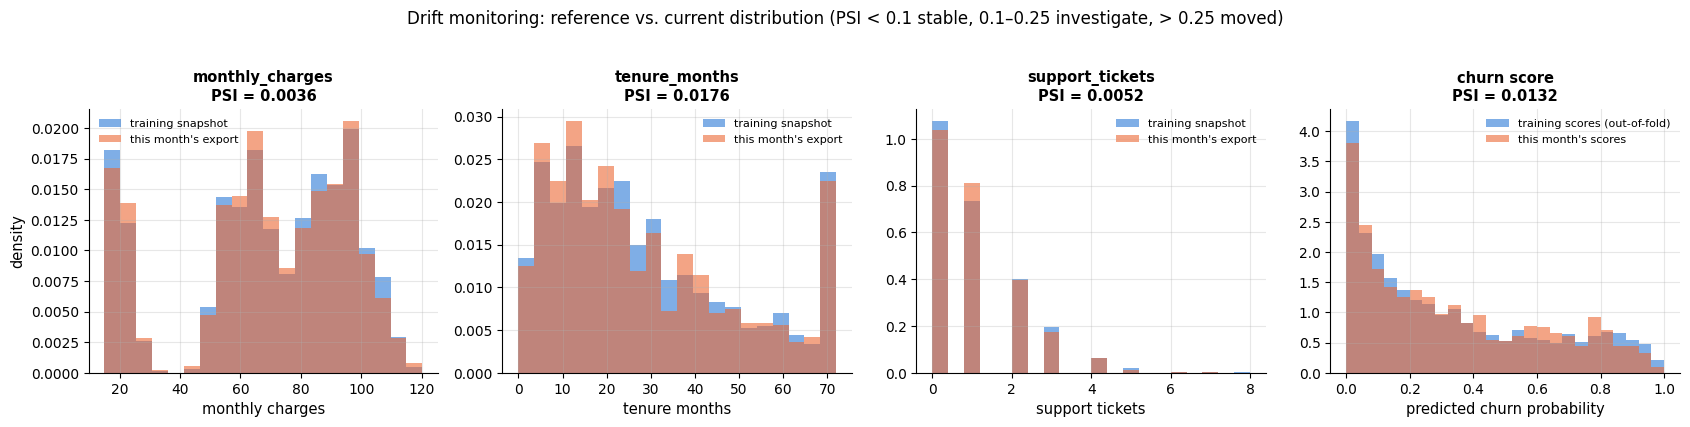

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.1))
for ax, col in zip(axes, ["monthly_charges", "tenure_months", "support_tickets"]):
    ref, cur = X_trval[col].dropna(), scored_features[col].dropna()
    edges = np.histogram_bin_edges(np.concatenate([ref, cur]), bins=20)
    ax.hist(ref, bins=edges, density=True, alpha=0.6, color=PALETTE[0], label="training snapshot")
    ax.hist(cur, bins=edges, density=True, alpha=0.6, color=PALETTE[1], label="this month's export")
    ax.set_title(f"{col}\nPSI = {psi(ref, cur):.4f}", fontsize=10.5)
    ax.set_xlabel(col.replace("_", " "))
    ax.legend(fontsize=8)
score_edges = np.linspace(0, 1, 26)
axes[3].hist(p_oof, bins=score_edges, density=True, alpha=0.6, color=PALETTE[0], label="training scores (out-of-fold)")
axes[3].hist(scored["p_churn"], bins=score_edges, density=True, alpha=0.6, color=PALETTE[1], label="this month's scores")
axes[3].set_title(f"churn score\nPSI = {psi(p_oof, scored['p_churn']):.4f}", fontsize=10.5)
axes[3].set_xlabel("predicted churn probability")
axes[3].legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("Drift monitoring: reference vs. current distribution (PSI < 0.1 stable, 0.1–0.25 investigate, > 0.25 moved)",
             y=1.03)
plt.tight_layout()
plt.show()

| What to watch | How | When | Threshold / action |
|---|---|---|---|
| **Input drift** | PSI per feature vs. the training snapshot; category shares for contract, payment, internet | every scoring run | PSI > 0.25 on any key feature → investigate before sending the list |
| **Score drift** | PSI of the churn-probability distribution; fraction above the value threshold | every run | a shift in the contacted fraction at the fixed threshold → recalibrate or re-tune |
| **Outcome quality** | realised churn of contacted vs. not-contacted customers, precision@15 %, AUC on last month's scores once labels arrive | monthly, one month lag | precision@15 % below the test CI's lower bound for two months → retrain |
| **Business value** | saved revenue estimated against a small randomised *control group* that is not contacted | every campaign | replaces the assumed $s = 0.3$ with a measurement; if the gain vanishes, stop the campaign |
| **Fairness** | selection rate, TPR by `senior_citizen` and `region` on the scored base | monthly | a gap that persists over three months → review with the policy owner |
| **Pipeline health** | schema check (columns, dtypes, ranges), row counts, missing-value rates in the export | every run | fail the job on a schema change |
| **Retraining** | retrain on a rolling window; compare the new model with the current one on the latest labelled month before switching | quarterly or on trigger | keep the previous model for rollback |

## 13. Report

What follows is the write-up that would go to the retention manager — one page, numbers
with uncertainty, decisions and their consequences, and what we do not know. (The
numbers are those printed above; re-running the notebook reproduces them.)

A one-page report deserves one page of figures. The six panels below are the ones a
stakeholder can read without help: how good the ranking is and how sure we are, what the
campaign catches, what it is worth against the alternatives, whether the probabilities can
be trusted, who the budget leaves out, and whether the offer reaches the groups evenly.

test-set precision@15%:  model 0.787   current rule of thumb 0.693   random 0.322


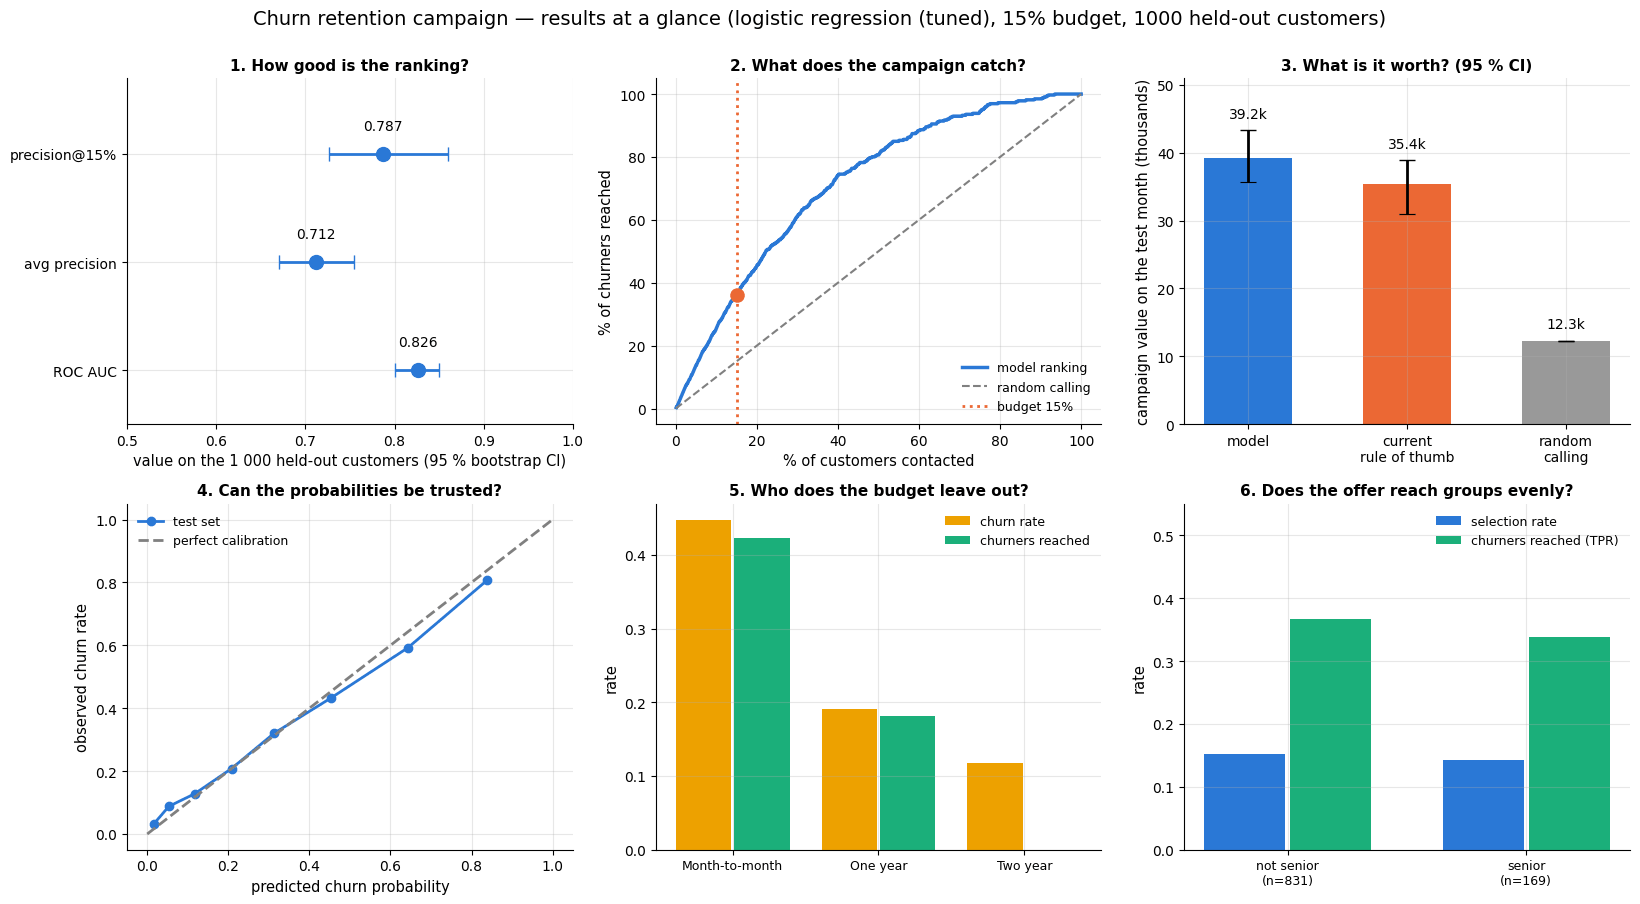

In [34]:
rng_glance = np.random.default_rng(0)
random_value = np.mean([realised_value(y_test, mc_test, top_k_mask(rng_glance.random(len(y_test))))
                        for _ in range(20)])
print(f"test-set precision@{BUDGET:.0%}:  model {precision_at_budget(y_test, v_test):.3f}   "
      f"current rule of thumb {precision_at_budget(y_test, heur_test):.3f}   "
      f"random {np.mean([precision_at_budget(y_test, rng_glance.random(len(y_test))) for _ in range(50)]):.3f}")

fig, axes = plt.subplots(2, 3, figsize=(16.5, 9))

ax = axes[0, 0]
glance_metrics = ["ROC AUC", "avg precision", "precision@15%"]
for i, metric in enumerate(glance_metrics):
    ax.errorbar(point[metric], i, xerr=[[point[metric] - ci.loc[metric, 0.025]], [ci.loc[metric, 0.975] - point[metric]]],
                fmt="o", ms=10, capsize=5, color=PALETTE[0])
    ax.text(point[metric], i + 0.22, f"{point[metric]:.3f}", ha="center", fontsize=10)
ax.set_yticks(range(len(glance_metrics)))
ax.set_yticklabels(glance_metrics)
ax.set_xlim(0.5, 1.0)
ax.set_ylim(-0.5, len(glance_metrics) - 0.3)
ax.set_xlabel("value on the 1 000 held-out customers (95 % bootstrap CI)")
ax.set_title("1. How good is the ranking?", fontsize=11)

ax = axes[0, 1]
order_test = np.argsort(-v_test)
frac_test = np.arange(1, len(y_test) + 1) / len(y_test)
captured_test = np.cumsum(y_test[order_test]) / y_test.sum()
ax.plot(frac_test * 100, captured_test * 100, lw=2.5, color=PALETTE[0], label="model ranking")
ax.plot([0, 100], [0, 100], color="gray", ls="--", lw=1.5, label="random calling")
ax.axvline(BUDGET * 100, color=PALETTE[1], ls=":", lw=2, label=f"budget {BUDGET:.0%}")
ax.scatter([BUDGET * 100], [captured_test[int(BUDGET * len(y_test)) - 1] * 100], color=PALETTE[1], s=90, zorder=5)
ax.set_xlabel("% of customers contacted")
ax.set_ylabel("% of churners reached")
ax.set_title("2. What does the campaign catch?", fontsize=11)
ax.legend(fontsize=9, loc="lower right")

ax = axes[0, 2]
value_names = ["model", "current\nrule of thumb", "random\ncalling"]
value_points = [point["campaign value (model)"], point["campaign value (heuristic)"], random_value]
value_err = [[point["campaign value (model)"] - ci.loc["campaign value (model)", 0.025],
              point["campaign value (heuristic)"] - ci.loc["campaign value (heuristic)", 0.025], 0],
             [ci.loc["campaign value (model)", 0.975] - point["campaign value (model)"],
              ci.loc["campaign value (heuristic)", 0.975] - point["campaign value (heuristic)"], 0]]
ax.bar(value_names, np.array(value_points) / 1000, yerr=np.array(value_err) / 1000, capsize=6,
       color=[PALETTE[0], PALETTE[1], "0.6"], width=0.55)
for i, (v, hi) in enumerate(zip(value_points, np.array(value_points) + np.array(value_err[1]))):
    ax.text(i, hi / 1000 + 1.8, f"{v / 1000:.1f}k", ha="center", fontsize=10)
ax.set_ylim(0, max(value_points) / 1000 * 1.3)
ax.set_ylabel("campaign value on the test month (thousands)")
ax.set_title("3. What is it worth? (95 % CI)", fontsize=11)

ax = axes[1, 0]
frac_pos_t, mean_pred_t = calibration_curve(y_test, p_test, n_bins=8, strategy="quantile")
ax.plot(mean_pred_t, frac_pos_t, marker="o", color=PALETTE[0], label="test set")
ax.plot([0, 1], [0, 1], color="gray", ls="--", label="perfect calibration")
ax.set_xlabel("predicted churn probability")
ax.set_ylabel("observed churn rate")
ax.set_title("4. Can the probabilities be trusted?", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1, 1]
contract_table = segment_tables["contract"]
x = np.arange(len(contract_table))
ax.bar(x - 0.2, contract_table["churn rate"].to_numpy(dtype=float), width=0.38, color=PALETTE[3], label="churn rate")
ax.bar(x + 0.2, contract_table["recall of contact list"].to_numpy(dtype=float), width=0.38, color=PALETTE[2],
       label="churners reached")
ax.set_xticks(x)
ax.set_xticklabels(contract_table.index, fontsize=9)
ax.set_ylabel("rate")
ax.set_title("5. Who does the budget leave out?", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1, 2]
senior = fairness_tables["senior_citizen"]
x = np.arange(len(senior))
for k, (metric, color) in enumerate(zip(["selection rate", "TPR"], [PALETTE[0], PALETTE[2]])):
    ax.bar(x + (k - 0.5) * 0.36, senior[metric].to_numpy(dtype=float), width=0.34, color=color,
           label=metric if metric != "TPR" else "churners reached (TPR)")
ax.set_xticks(x)
ax.set_xticklabels([f"not senior\n(n={int(senior['n'].iloc[0])})", f"senior\n(n={int(senior['n'].iloc[1])})"], fontsize=9)
ax.set_ylabel("rate")
ax.set_ylim(0, 0.55)
ax.set_title("6. Does the offer reach groups evenly?", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle(f"Churn retention campaign — results at a glance ({FINAL_NAME}, {BUDGET:.0%} budget, "
             f"{len(y_test)} held-out customers)", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

> **Summary.** We built a model that ranks customers by the expected value of a retention
> contact and evaluated it on 1 000 customers the model never saw. Following its ranking
> with the current budget (15 % of customers) reaches a precision of about 0.78 on
> the contact list — roughly four out of five customers called would indeed have left —
> against 0.32 for random calling and about 0.69 for the current rule of thumb
> (month-to-month customers with the highest bills). In campaign value the model beats
> the rule of thumb by a margin whose 95 % confidence interval excludes zero; the absolute
> gain is modest, because the rule of thumb is already good.
>
> **Recommendations.** (1) Use the model's ranking for the next campaign, keeping a
> randomly chosen 10 % of the would-be-contacted customers *out* of the campaign as a
> control group, so that the assumed 30 % retention success can be measured. (2) Consider
> a larger budget: the gains curve keeps rising well past 15 % — contacting everyone for
> whom a call pays off in expectation would be roughly four fifths of the base — so we can
> quantify the value of any budget on request. (3) Record with the policy owner that
> `senior_citizen` is used as a feature: seniors are contacted and reached at rates within
> sampling noise of everyone else, but using the attribute at all is a decision that should
> be made deliberately rather than by default.
>
> **Limitations.** The value calculation assumes every retained customer stays twelve
> more months and ignores customers who would have stayed without the offer; both will be
> corrected once control-group data exist. The model is trained on a single snapshot of
> 4 000 customers and must be monitored for drift (plan attached). Customers on long
> contracts are rarely contacted under this budget; they are few, but valuable.
>
> **Next steps.** Run the campaign with the control group; add usage and
> customer-service data as features (the learning curve shows more rows alone will not
> help); revisit the model after the first labelled campaign month.

In [35]:
print(f"Part I executed in {time.perf_counter() - T_START:.0f} s")

Part I executed in 18 s


# Part II — Your own project

## 14. Project template

Whatever the dataset, a complete project delivers the same eight things. Use this as the
skeleton of your notebook (or repository) and as a checklist before you call it done.

| # | Section | What must be in it | Notebooks |
|---|---|---|---|
| 1 | **Problem framing** | the decision the model supports; the success metric and why; constraints (budget, latency, fairness, interpretability); a baseline | 5, 7, 19 |
| 2 | **Data** | source, size, how it was collected, known quality issues and how you handled them; the split protocol (stratified / grouped / time-based) and *when* you split | 3, 4, 5, 16 |
| 3 | **Features and pipeline** | feature engineering with the reasoning; a `Pipeline`/`ColumnTransformer` that makes leakage impossible | 4, 5 |
| 4 | **Models** | baselines, 2–4 model families, cross-validated scores with standard errors, a small tuning study, model selection with a stated rule | 6–12, 15–16 |
| 5 | **Decision** | how scores become actions (threshold, budget, cost matrix); calibration evidence | 7 |
| 6 | **Evaluation** | held-out results with confidence intervals; error analysis by segment; explanations (global + local); fairness check where people are affected | 5, 17, 19 |
| 7 | **Packaging** | persisted pipeline + metadata, model card, a scoring function tested on a new file, a monitoring plan | 18 |
| 8 | **Report** | one page: summary, recommendations, limitations, next steps — written for the decision maker | 20 (this notebook, §13) |

The same eight steps, as the map to pin above the desk — with the notebook that explains
each one. The arrows are the order in which the decisions constrain each other, not the
order in which you will end up doing them: real projects loop back from 6 to 3 more than
once.

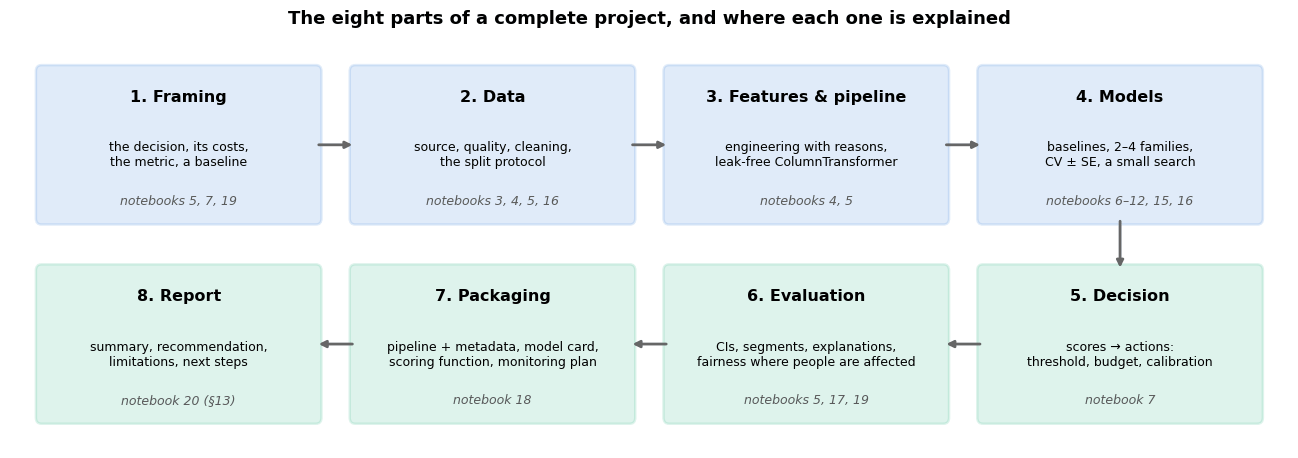

In [36]:
from matplotlib.patches import FancyBboxPatch

steps = [("1. Framing", "the decision, its costs,\nthe metric, a baseline", "notebooks 5, 7, 19"),
         ("2. Data", "source, quality, cleaning,\nthe split protocol", "notebooks 3, 4, 5, 16"),
         ("3. Features & pipeline", "engineering with reasons,\nleak-free ColumnTransformer", "notebooks 4, 5"),
         ("4. Models", "baselines, 2–4 families,\nCV ± SE, a small search", "notebooks 6–12, 15, 16"),
         ("5. Decision", "scores → actions:\nthreshold, budget, calibration", "notebook 7"),
         ("6. Evaluation", "CIs, segments, explanations,\nfairness where people are affected", "notebooks 5, 17, 19"),
         ("7. Packaging", "pipeline + metadata, model card,\nscoring function, monitoring plan", "notebook 18"),
         ("8. Report", "summary, recommendation,\nlimitations, next steps", "notebook 20 (§13)")]
positions = [(i, 0) for i in range(4)] + [(i, 1) for i in (3, 2, 1, 0)]

fig, ax = plt.subplots(figsize=(16.5, 5.4))
box_w, box_h, dx, dy = 3.5, 1.7, 4.0, 2.3
for (title, what, books), (col, row) in zip(steps, positions):
    x, y = col * dx, -row * dy
    ax.add_patch(FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.07",
                                facecolor=PALETTE[0] if row == 0 else PALETTE[2], alpha=0.14,
                                edgecolor=PALETTE[0] if row == 0 else PALETTE[2], lw=1.8))
    ax.text(x + box_w / 2, y + box_h - 0.3, title, ha="center", va="center", fontsize=11.5, fontweight="semibold")
    ax.text(x + box_w / 2, y + box_h / 2 - 0.12, what, ha="center", va="center", fontsize=9)
    ax.text(x + box_w / 2, y + 0.2, books, ha="center", va="center", fontsize=9, style="italic", color="0.35")
for k in range(len(steps) - 1):
    (c0, r0), (c1, r1) = positions[k], positions[k + 1]
    if r0 == r1:
        sign = 1 if c1 > c0 else -1
        start = (c0 * dx + (box_w if sign > 0 else 0), -r0 * dy + box_h / 2)
        end = (c1 * dx + (0 if sign > 0 else box_w), -r1 * dy + box_h / 2)
    else:
        start = (c0 * dx + box_w / 2, -r0 * dy)
        end = (c1 * dx + box_w / 2, -r1 * dy + box_h)
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", color="0.4", lw=2))
ax.set_xlim(-0.4, 3 * dx + box_w + 0.4)
ax.set_ylim(-dy - 0.35, box_h + 0.45)
ax.axis("off")
ax.set_title("The eight parts of a complete project, and where each one is explained", fontsize=13)
plt.show()

Keep two documents from the start: a **decision log** (every choice you made, why, and
what you rejected) and a **question list** for the domain owner. Both end up in the
report, and both are what distinguishes a project from a script.

## 15. Three alternative projects

Each brief below can be completed in the same time as Part I. Milestones are cumulative;
the number in brackets is a rough share of the effort.

### Project A — Day-ahead electricity demand forecasting (`load_energy_demand()`)

*Brief.* A grid operator needs, every day at 09:00, a forecast of hourly demand for the
next 24 hours, with an uncertainty band, using the hourly history and the temperature
forecast.

1. **Framing (10 %)** — forecast horizon and origin; metric MAE/MASE (notebook 16) against the *seasonal naive* baseline (same hour last week); a business reason for the band (reserve capacity).
2. **Backtesting design (15 %)** — rolling-origin evaluation over the last 3 months of the two-year series; no random splits.
3. **Features (20 %)** — lags (24 h, 168 h), rolling statistics *shifted* to avoid leakage, calendar and holiday features, Fourier terms, temperature and its non-linear effect.
4. **Models (25 %)** — seasonal naive → ridge on lags → `HistGradientBoostingRegressor`; direct multi-step strategy; a Holt–Winters or SARIMA comparison if `statsmodels` is available.
5. **Uncertainty and evaluation (15 %)** — quantile regression or residual-based intervals; coverage check; error by hour of day and by weekday/holiday.
6. **Packaging and report (15 %)** — a `forecast(origin)` function, a drift check on temperature, a model card, a report for the operator.

### Project B — Review sentiment and topic analysis (`load_reviews()`)

*Brief.* A product team wants an automatic weekly digest of customer reviews: the share of
negative reviews per product, the topics that drive negativity, and a flag on reviews
that need a human reply.

1. **Framing (10 %)** — two tasks: sentiment classification (metric: precision–recall of the *negative* class, since those get answered) and topic discovery (no ground truth — evaluate by coherence and usefulness).
2. **Text pipeline (20 %)** — tokenisation, `TfidfVectorizer` with word and character n-grams, `min_df` (notebook 15); a duplicate check across the split.
3. **Models (25 %)** — naive Bayes → logistic regression → linear SVM; cross-validated with a small grid; the most informative features per class; error analysis on the misclassified reviews (negation, sarcasm).
4. **Topics (20 %)** — NMF/LDA on the negative reviews per product; label the topics by hand; check that they are stable across random seeds.
5. **Fairness and robustness (10 %)** — is accuracy equal across products and review lengths? What happens to a review with a typo, or written in another register?
6. **Packaging and report (15 %)** — a `digest(reviews_this_week)` function that writes a Markdown report; a model card; a plan for handling reviews the classifier is unsure about.

### Project C — Fair lending (`load_loans()`)

*Brief.* A lender wants to replace manual loan approvals with a model, and its compliance
team wants evidence that the model does not discriminate.

1. **Framing (15 %)** — the decision and its costs (a default vs. a lost customer); *which* label to train on and why (notebook 19: `approved` vs `repaid`); the fairness criterion, argued for, with the impossibility theorem acknowledged; the applicable regulation (AI Act: high-risk).
2. **Audit of the data (15 %)** — approval and repayment by group; proxies (a proxy audit); a datasheet.
3. **Models (20 %)** — logistic regression and gradient boosting on the outcome label, with and without proxies; calibration by group.
4. **Fairness evaluation and intervention (25 %)** — the full metric set at the deployed threshold; reweighing vs. group-specific thresholds; the profit–fairness Pareto front; a recommendation.
5. **Explanations and recourse (10 %)** — global importance; a counterfactual explanation for a denied applicant ("what would need to change"); how an applicant contests a decision.
6. **Packaging and report (15 %)** — model card with disaggregated metrics; a monitoring plan that includes the fairness metrics and the *selective-labels* problem (outcomes are only observed for approved loans).

## 16. Grading rubric

Use it to grade yourself, or a peer. Each criterion is scored 0–4; the descriptions give
the 4 (and, in brackets, what typically costs points).

| Criterion | Weight | What a 4 looks like |
|---|---|---|
| **Problem framing** | 15 % | The decision, its costs and the metric are stated before any modelling, and the metric follows from the decision. *(Accuracy chosen "because it is the default".)* |
| **Validation protocol** | 15 % | Split before fitting anything; CV appropriate to the data (stratified / grouped / temporal); the test set used once; standard errors reported. *(Scaler fitted on the full data; tuning on the test set; "best of 50 runs".)* |
| **Feature engineering and pipeline** | 10 % | Features justified by EDA or domain knowledge; every fitted step inside a `Pipeline`; new data can be scored with the same code. *(Manual preprocessing that cannot be reproduced on new data.)* |
| **Modelling and selection** | 15 % | Baselines and a strong simple model; a small, deliberate tuning study; the selection rule stated and applied. *(Only one model, or a huge search with no uncertainty.)* |
| **Decision and calibration** | 10 % | Scores become actions through a stated rule that respects the constraints; calibration checked when probabilities are used as such. *(Threshold 0.5 by default.)* |
| **Evaluation and error analysis** | 15 % | Confidence intervals on the test metrics; segment analysis; a fairness check where relevant; explanations sanity-checked against domain knowledge. *(A single number.)* |
| **Packaging and monitoring** | 10 % | Persisted pipeline with metadata; a model card; a scoring function tested on a new file; a monitoring plan with thresholds and actions. *(A notebook that only its author can run.)* |
| **Report and communication** | 10 % | A page a manager can act on; numbers with uncertainty; limitations stated honestly; figures with titles, labels and a point. *(Screenshots of `df.head()`; no limitations.)* |

## 17. Presenting results

A few rules that survive contact with real audiences:

- **Lead with the decision, not the model.** "Calling the 15 % of customers the model
  ranks highest saves an estimated X ± Y per campaign" is the first sentence; the model
  family is a footnote.
- **One number per claim, with an interval.** Never a table of eight metrics to four
  decimals; the metric that matches the decision, and its uncertainty.
- **Compare to what exists.** The baseline row — random, the current rule, the previous
  model — is the most important row in every table.
- **Show the trade-off curve** (gains curve, Pareto front, precision–recall) rather than a
  point on it; the audience owns the choice of operating point.
- **Say what you do not know**, and what would resolve it (a control group, more data of a
  specific kind, a domain review). Credibility comes from the limitations section.
- **Reproducibility is part of the result:** the notebook runs top to bottom, the seed
  is fixed, the environment is pinned, the artefacts have a version.

## 18. Where to go next

This course was deliberately a *classical* machine-learning course: twenty notebooks on
data work, linear and probabilistic models, trees and ensembles, kernels, unsupervised
learning, text, time series, interpretability, engineering and ethics — everything except
neural networks, which have a dedicated course of their own. That boundary is the map for
what comes next.

- **Read the classics slowly.** *An Introduction to Statistical Learning* (James et al.,
  2023) and *The Elements of Statistical Learning* (Hastie et al., 2009) remain the best
  second pass over everything in notebooks 5–14; Murphy (2022) for the probabilistic view;
  Barocas, Hardt & Narayanan (2023) for fairness; Huyen (2022) for production systems.
  Prince (2023) or Goodfellow et al. (2016) when you move on to the deep-learning course.
- **Domingos (2012) and Google's *Rules of Machine Learning*** are short and worth
  re-reading every year — they age well because they are about judgement, not tools.
- **Compete, carefully.** Kaggle and similar competitions teach validation discipline and
  feature engineering faster than anything else; they teach nothing about framing,
  fairness or deployment, so treat them as one gym among several.
- **Reproduce a paper.** Pick a paper with code, reproduce its main table, then change
  one thing. This is how research skill starts.
- **Build for someone.** The projects above are stronger with a real "client" — a
  colleague, a club, an open-data community — who will ask the questions this course kept
  asking: *what decision, what cost, what happens when it is wrong?*
- **Specialise deliberately:** deep learning for vision or language (a dedicated deep-learning course, then the PyTorch and Hugging Face tutorial ecosystems), time series (Hyndman &
  Athanasopoulos, 2021), reinforcement learning (Sutton & Barto, 2018), causal inference
  (the natural next step after notebook 19's counterfactual questions), or ML engineering
  (Huyen, 2022; Kleppmann, 2017).

## Summary

- A project starts with a **decision**; the metric, the split, the threshold and the
  monitoring plan all follow from it. Write the decision and its costs down first.
- **Baselines** (random, the current rule) are the most informative rows of the model
  table; learned models must beat them by more than a standard error to matter.
- **Compare models with cross-validated uncertainty**, tune modestly, and select with a
  stated rule — the one-standard-error rule favours the simplest model that is
  statistically tied with the best.
- Turn probabilities into actions through **expected value under the budget**, after
  checking calibration; show the gains curve so that the budget itself can be discussed.
- Report **held-out metrics with bootstrap intervals**, **error analysis by segment**,
  **explanations** that pass a domain sanity check, and a **fairness check** on the
  groups the decision affects.
- Ship the **pipeline + metadata + model card + scoring function + monitoring plan**,
  and a **one-page report** that leads with the decision and ends with the limitations.

| Step | Key tool | Notebook |
|---|---|---|
| Framing, metric, baseline | cost/value model, `DummyClassifier`, a business rule | 5, 7 |
| Cleaning and EDA | `drop_duplicates`, `.str.title()`, target-oriented group rates | 3, 4 |
| Leak-free features | `ColumnTransformer`, `Pipeline`, `SimpleImputer`, `OneHotEncoder` | 4, 5 |
| Comparison with uncertainty | `cross_validate`, mean ± SE, `make_scorer` | 5, 7 |
| Tuning and selection | `RandomizedSearchCV`, one-SE rule, `LearningCurveDisplay` | 5, 12 |
| Decision under a budget | `cross_val_predict`, `calibration_curve`, expected value, gains curve | 7 |
| Held-out evaluation | bootstrap CIs, paired differences, segment tables | 2, 5 |
| Explanations | `permutation_importance`, `PartialDependenceDisplay`, what-if attribution | 17 |
| Fairness | selection rate / TPR / FPR by group | 19 |
| Packaging and monitoring | `joblib`, metadata JSON, model card, `score_file`, PSI | 18 |

## Exercises

### Exercise 1 — The value of a bigger budget (easy)
Recompute the campaign value on the test set for budgets of 5 %, 10 %, 15 %, 25 % and
40 %, with bootstrap intervals, and write the two sentences the retention manager needs
to decide whether to ask for more budget.

<details><summary>Solution sketch</summary>

Loop over budgets, reuse `top_k_mask(v_test, budget)` and `realised_value`, and bootstrap
as in section 7. The *marginal* value per contact falls as the budget grows (the
expected-value ranking is decreasing by construction); the break-even budget is where
$v_i$ crosses zero — report that point and the value at each budget.
</details>

### Exercise 2 — One more row in the comparison table (easy)
Add scikit-learn's `MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, early_stopping=True, max_iter=500)`
to the comparison of section 4, inside the same pipeline, and add it to the dot-and-error-bar
chart. Does it earn a place in the table — and would you defend that choice to the
retention team?

<details><summary>Solution sketch</summary>

With standardised numerics and one-hot categoricals the MLP lands within a standard error
of logistic regression, at several times the fit time; on 4 000 rows there is not enough
signal for it to learn interactions that the engineered features do not already encode, so
it does not change the selection. That is the usual tabular result (Grinsztajn et al.,
2022), and it is why this course treats neural models as one row of a comparison table;
building them properly is the subject of a dedicated deep-learning course.
</details>

### Exercise 3 — Uplift, not churn (medium)
The campaign should target customers whose behaviour the offer *changes*, not those most
likely to churn. Simulate a control group: assume the offer works only for month-to-month
customers with fewer than two tickets ($s = 0.5$ there, $0$ elsewhere), recompute the
expected value with this customer-specific $s$, and compare the two contact lists. Which
customers disappear from the list, and why is a randomised control group the only way to
*learn* $s$ from data?

<details><summary>Solution sketch</summary>

Replace `S_RETAIN` by a per-customer vector in `expected_value`; customers with many
tickets drop off the list (they will churn, but the offer will not stop them). Without
randomisation, contacted and not-contacted customers differ systematically, so the
observed retention of contacted customers confounds the offer's effect with the selection
— the uplift literature (two-model and transformed-outcome approaches) starts from this
observation.
</details>

### Exercise 4 — Calibration layer (medium)
Wrap the tuned boosting model in `CalibratedClassifierCV(method="isotonic", cv=5)` and
compare Brier score, log loss and the campaign value at 15 % with the uncalibrated version
using `cross_val_predict`. When does calibration change the *ranking*, and hence the
decision?

<details><summary>Solution sketch</summary>

Isotonic regression is monotone, so within one model it never changes the ranking by
probability — but it does change the ranking by *expected value*, because $v_i$
multiplies the probability by the monthly charge; over-confident probabilities inflate
the value of high-bill customers. Expect a small Brier improvement and a slightly
different contact list at the margin.
</details>

### Exercise 5 — Equal opportunity across seniors (medium)
Suppose policy requires churners among seniors and non-seniors to be contacted at
*exactly* the same rate. Implement group-specific value thresholds (notebook 19,
section 4.4) that equalise the true positive rates under the 15 % budget, and quantify
the cost in campaign value.

<details><summary>Solution sketch</summary>

For a common target TPR $t$, find in each group the value threshold that reaches $t$;
sweep $t$ until the total contacted fraction equals 15 %. The cost is small here because
the TPRs are already close; report it with a bootstrap interval so that "small" has a
number.
</details>

### Exercise 6 — Your project (hard)
Choose one of the briefs in section 15, complete all milestones, and grade the result
with the rubric in section 16. Then swap reports with someone and grade each other's.

<details><summary>Solution sketch</summary>

There is no solution to look up — but there is a test: give the report and the artefacts
to someone who has not seen the code and ask them to (a) state the decision the model
supports, (b) score a new file, and (c) name the model's two biggest limitations. If they
can, the project is done.
</details>

## References and further reading

### Textbooks

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — The best single book to re-read after this course.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 7 for the model-assessment machinery used throughout Part I.
- Huyen, C. (2022). *Designing Machine Learning Systems*. O'Reilly. — The production side of a project: data, deployment, monitoring, iteration.
- Burkov, A. (2020). *Machine Learning Engineering*. True Positive Inc. (free "read first, buy later" at http://www.mlebook.com) — A compact, practical account of the whole life cycle.
- Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press. (free) — For the feature-engineering step, with many worked case studies.
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. (free) — For Project C and the fairness check.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. (free) — For Project A.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 2 is an end-to-end project in the same spirit as Part I.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free at https://probml.github.io/pml-book/book1.html) — The probabilistic second pass over most of this course, recommended in section 18.
- Prince, S. J. D. (2023). *Understanding Deep Learning*. MIT Press. (free at https://udlbook.github.io/udlbook/); and Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. (free at https://www.deeplearningbook.org) — For the neural-network material this course deliberately leaves to a dedicated deep-learning course.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. (free at http://incompleteideas.net/book/the-book.html) — For the reinforcement-learning direction of section 18.
- Kleppmann, M. (2017). *Designing Data-Intensive Applications*. O'Reilly. — The data-systems background behind the ML-engineering direction of section 18.

### Papers

- Domingos, P. (2012). A few useful things to know about machine learning. *Communications of the ACM*, 55(10), 78–87. — Twelve lessons, every one of which appears somewhere in Part I.
- Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep learning on typical tabular data? *NeurIPS 2022 Datasets and Benchmarks*. — Context for the model comparison of sections 4–5.
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *The Annals of Statistics*, 7(1), 1–26. — The confidence intervals of section 7.
- Fisher, A., Rudin, C., & Dominici, F. (2019). All models are wrong, but many are useful: learning a variable's importance by studying an entire class of prediction models simultaneously. *Journal of Machine Learning Research*, 20(177), 1–81. — Permutation importance.
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *The Annals of Statistics*, 29(5), 1189–1232. — Gradient boosting and partial dependence plots.
- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *Proceedings of ICML 2005*, 625–632. — Which models need a calibration layer.
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *Advances in NIPS 29*. — The criterion behind the fairness check and exercise 5.
- Mitchell, M., et al. (2019). Model cards for model reporting. *Proceedings of FAT\* 2019*, 220–229. — The template of section 11.
- Sculley, D., et al. (2015). Hidden technical debt in machine learning systems. *Advances in NIPS 28*; and Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). The ML test score: a rubric for ML production readiness and technical debt reduction. *Proceedings of IEEE Big Data 2017*. — Why sections 11–12 exist.
- Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). A survey on concept drift adaptation. *ACM Computing Surveys*, 46(4), 1–37. — Background for the monitoring plan.
- Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research*, 11, 2079–2107. — Why the test set is used once, after the search.

### Documentation and online resources

- Google, *Rules of Machine Learning* (M. Zinkevich) — https://developers.google.com/machine-learning/guides/rules-of-ml — Rule #1 through Rule #43; read before starting any project.
- scikit-learn user guide, *Common pitfalls and recommended practices* — https://scikit-learn.org/stable/common_pitfalls.html
- scikit-learn user guide, *Model persistence* — https://scikit-learn.org/stable/model_persistence.html
- scikit-learn user guide, *Inspection* (permutation importance, partial dependence) — https://scikit-learn.org/stable/inspection.html
- The course itself: notebooks 00–20, each with its own reading list. The map in section 14 says which one to reopen for each step of a project.